# Customer Lifecycle & RFM Analysis

This project analyzes customer purchasing behavior and lifecycle using transaction-level data from the [Online Retail II dataset](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci/data).

The analysis focuses on customer retention, churn, lifetime value (LTV), cohort behavior, and RFM segmentation to identify valuable customer segments and customers at risk of churn.

The analysis also distinguishes between Retail and Wholesale customers based on purchasing behavior, allowing customer lifecycle patterns to be evaluated separately.

## Import Libraries

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Cleaning & Data Quality

### Load data and Data Overview

In [166]:
import kagglehub

path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
Path to dataset files: /kaggle/input/online-retail-ii-uci


In [167]:
import os
os.listdir(path)

['online_retail_II.csv']

In [168]:
file_path = f"{path}/online_retail_II.csv"

df = pd.read_csv(file_path)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [170]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice,1067371,53628,537434,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,172.705794,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,1067371,47635,2010-12-06 16:57:00,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,1697.46445,12346.0,13975.0,15255.0,16797.0,18287.0
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [171]:
print("First date:", df['InvoiceDate'].min())
print("Last date:", df['InvoiceDate'].max())

First date: 2009-12-01 07:45:00
Last date: 2011-12-09 12:50:00


In [172]:
df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,981330
EIRE,17866
Germany,17624
France,14330
Netherlands,5140
Spain,3811
Switzerland,3189
Belgium,3123
Portugal,2620


The dataset contains 1 067 371 transaction records across 8 columns, covering the period from December 1 2009 to December 9 2011.

It contains 53 628 unique invoices and data from 43 countries. The United Kingdom is the dominant market.

Customer ID and Description contain missing values, while InvoiceDate is currently stored as an object and will be converted to a datetime format during the data cleaning stage.

The initial descriptive statistics also reveal unusual values in Quantity and Price, which will be investigated separately during the data cleaning process.

### Missing CustomerID

In [173]:
missing_customers = df['Customer ID'].isna().sum()
missing_customers_pct = df['Customer ID'].isna().mean()

print(f"Rows without Customer ID: {missing_customers}")
print(f"Share of rows without Customer ID: {missing_customers_pct:.2%}")

Rows without Customer ID: 243007
Share of rows without Customer ID: 22.77%


Customer-level analysis requires a valid Customer ID. Without it, individual transactions cannot be reliably assigned to customers, making cohort analysis, retention, churn, LTV, and RFM segmentation impossible for those records.

Transactions without Customer ID will be excluded from customer-level analysis.

### Cancelled invoices

In [174]:
cancelled = df['Invoice'].str.startswith('C')

print(f'Rows with cancelled invoices: {cancelled.sum()}')
print(f'Canceled rows share: {cancelled.mean():.2%}')
print(f"Cancelled invoices: {df.loc[cancelled, 'Invoice'].nunique()}")

Rows with cancelled invoices: 19494
Canceled rows share: 1.83%
Cancelled invoices: 8292


Invoices starting with 'C' represent cancelled transactions rather than completed purchases. They account for 19 494 transaction rows (1.83% of the dataset) across 8 292 unique invoices.

Since these records do not represent completed purchases, they will be excluded from purchase-based customer analysis, including cohort analysis, retention, churn, LTV, and RFM segmentation.

### Negative quantities & Price

In [175]:
negative_qty = df['Quantity'] < 0
print(f'Rows with negative quantities: {negative_qty.sum()}')
print(f'Negative quantities rows share: {negative_qty.mean():.2%}')
print(f"Negative quantities invoices: {df.loc[negative_qty, 'Invoice'].nunique()}")

Rows with negative quantities: 22950
Negative quantities rows share: 2.15%
Negative quantities invoices: 11684


In [176]:
# do all negative quantities belong to canceled orders?
df.loc[df['Quantity'] < 0, 'Invoice'].str.startswith('C').value_counts()

,count
Invoice,
True,19493
False,3457


In [177]:
negative_non_cancelled = df[(df['Quantity'] < 0) &(~df['Invoice'].str.startswith('C'))]

negative_non_cancelled[['Invoice', 'Description', 'Quantity', 'Price']].head(10)

,Invoice,Description,Quantity,Price
263,489464,85123a mixed,-96,0.0
283,489463,short,-240,0.0
284,489467,21733 mixed,-192,0.0
470,489521,NaN,-50,0.0
3114,489655,NaN,-44,0.0
3162,489660,lost,-1043,0.0
3168,489663,damages,-117,0.0
4296,489806,NaN,-770,0.0
4538,489820,invcd as 84879?,-720,0.0
4566,489821,NaN,-240,0.0


In [178]:
negative_non_cancelled['Description'].value_counts().head(10)

,count
Description,
check,123
damages,84
?,83
damaged,78
missing,27
sold as set on dotcom,20
Damaged,17
smashed,9
thrown away,9


Among the 22 950 rows with negative Quantity:

- 19 493 rows are associated with invoices starting with 'C' and represent cancellations.
- 3 457 rows have negative Quantity but do not have a 'C' invoice prefix.

The non-cancelled negative-quantity records contain descriptions such as *'check',	'damages','?', 'missing', 'sold as set on dotcom', 'smashed', 'thrown away', 'Unsaleable, destroyed'*. These indicate adjustments, damaged/missing goods, or other non-standard transactions rather than regular customer purchases.


Negative-quantity records will be excluded from the purchase dataset because they do not represent completed product purchases. This includes both cancelled transactions and other non-standard negative-quantity adjustments.

In [179]:
negative_prc = df['Price'] < 0

print(f"Rows with negative prices: {negative_prc.sum():,}")
print(f"Negative price rows share: {negative_prc.mean():.2%}")
print(f"Negative price invoices: {df.loc[negative_prc, 'Invoice'].nunique():,}")

Rows with negative prices: 5
Negative price rows share: 0.00%
Negative price invoices: 5


In [180]:
df[negative_prc][['Invoice', 'Description', 'Quantity', 'Price']].head()

,Invoice,Description,Quantity,Price
179403,A506401,Adjust bad debt,1,-53594.36
276274,A516228,Adjust bad debt,1,-44031.79
403472,A528059,Adjust bad debt,1,-38925.87
825444,A563186,Adjust bad debt,1,-11062.06
825445,A563187,Adjust bad debt,1,-11062.06


Only 5 rows have a negative Price.

All five records are labelled *'Adjust bad debt'* and represent bad-debt adjustments rather than product purchases.

These records will be excluded from the purchase dataset because they do not represent actual product sales.

### Duplicates

In [181]:
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicate rows share: {df.duplicated().mean():.2%}")

Duplicate rows: 34,335
Duplicate rows share: 3.22%


In [182]:
df[df.duplicated(keep=False)].sort_values(['Invoice', 'StockCode']).head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom


The dataset contains 34 335 duplicate rows (3.22%).

The duplicates have identical values across all columns, including *'Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', and 'Country'*. The only difference is the DataFrame index, which is not part of the transaction data.

These are true duplicate records rather than separate purchases or different products within the same invoice.

Duplicate rows will be removed from the cleaned dataset to prevent double-counting transactions, quantities, revenue, and customer activity.

### Cleaning

In [183]:
df_clean = df.copy()
df_clean.shape

(1067371, 8)

In [184]:
# remove missing Customer ID
df_clean = df_clean.dropna(subset=['Customer ID'])
df_clean.shape

(824364, 8)

In [185]:
# remove cancelled invoices
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C')]
df_clean.shape

(805620, 8)

In [186]:
# remove negative Quantity
df_clean = df_clean[df_clean['Quantity'] >= 0]
df_clean.shape

(805620, 8)

In [187]:
# remove negative Price
df_clean = df_clean[df_clean['Price'] >= 0]
df_clean.shape

(805620, 8)

In [188]:
# remove duplicated rows
df_clean = df_clean.drop_duplicates()
df_clean.shape

(779495, 8)

The cleaned dataset contains 779 495 rows and 8 columns.

The following records were excluded:

- Transactions without 'Customer ID'
- Cancelled invoices ('Invoice' starting with 'C')
- Negative quantities
- Negative prices
- Duplicated rows


### Date & Data Types

In [189]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779495 non-null  object 
 1   StockCode    779495 non-null  object 
 2   Description  779495 non-null  object 
 3   Quantity     779495 non-null  int64  
 4   InvoiceDate  779495 non-null  object 
 5   Price        779495 non-null  float64
 6   Customer ID  779495 non-null  float64
 7   Country      779495 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 53.5+ MB


In [190]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [191]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

df_clean['Customer ID'] = df_clean['Customer ID'].astype('int16')

In [192]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779495 non-null  object        
 1   StockCode    779495 non-null  object        
 2   Description  779495 non-null  object        
 3   Quantity     779495 non-null  int64         
 4   InvoiceDate  779495 non-null  datetime64[ns]
 5   Price        779495 non-null  float64       
 6   Customer ID  779495 non-null  int16         
 7   Country      779495 non-null  object        
dtypes: datetime64[ns](1), float64(1), int16(1), int64(1), object(4)
memory usage: 49.1+ MB


'InvoiceDate' was converted to datetime to enable date-based analysis such as monthly cohorts, retention periods, recency and churn.

'Customer ID' was converted from 'float64' to 'int16' because missing IDs were removed during cleaning and all remaining customer IDs fit within the 'int16' range.

### Create Revenue column

In [193]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [194]:
df_clean['Revenue'].describe()

,Revenue
count,779495.000000
mean,22.289821
std,227.416962
min,0.000000
25%,4.950000
50%,12.480000
75%,19.800000
max,168469.600000


In [195]:
df_clean[df_clean['Revenue'] == 0][['Invoice', 'StockCode', 'Description', 'Quantity', 'Price']].head(30)

,Invoice,StockCode,Description,Quantity,Price
4674,489825,22076,6 RIBBONS EMPIRE,12,0.0
6781,489998,48185,DOOR MAT FAIRY CAKE,2,0.0
16107,490727,M,Manual,1,0.0
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,0.0
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,0.0
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,0.0
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,0.0
47126,493761,79320,FLAMINGO LIGHTS,24,0.0
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,0.0
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,0.0


In [196]:
zero_revenue = df_clean['Revenue'] == 0

print(f"Zero revenue rows: {zero_revenue.sum():,}")
print(f"Zero revenue share: {zero_revenue.mean():.2%}")

Zero revenue rows: 70
Zero revenue share: 0.01%


After calculating Revenue, 70 rows (0.01%) have zero revenue.

These records contain zero-priced items, including a small number of technical/test entries. Since they represent only 0.01% of the cleaned dataset, they are retained and are not expected to materially affect the analysis.

## EDA

### Time coverage

In [197]:
print(f'Data range: from {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}')
print(f'Months coverage {round(((df_clean['InvoiceDate'].max() - df_clean['InvoiceDate'].min()).days) / 30.44 , 1)}')

Data range: from 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Months coverage 24.2


In [198]:
monthly_sales = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M')).agg(orders=('Invoice', 'nunique'), revenue=('Revenue', 'sum')).reset_index()
monthly_sales.head()

,InvoiceDate,orders,revenue
0,2009-12,1512,683504.010
1,2010-01,1011,555802.672
2,2010-02,1106,504558.956
3,2010-03,1524,696978.471
4,2010-04,1329,591982.002


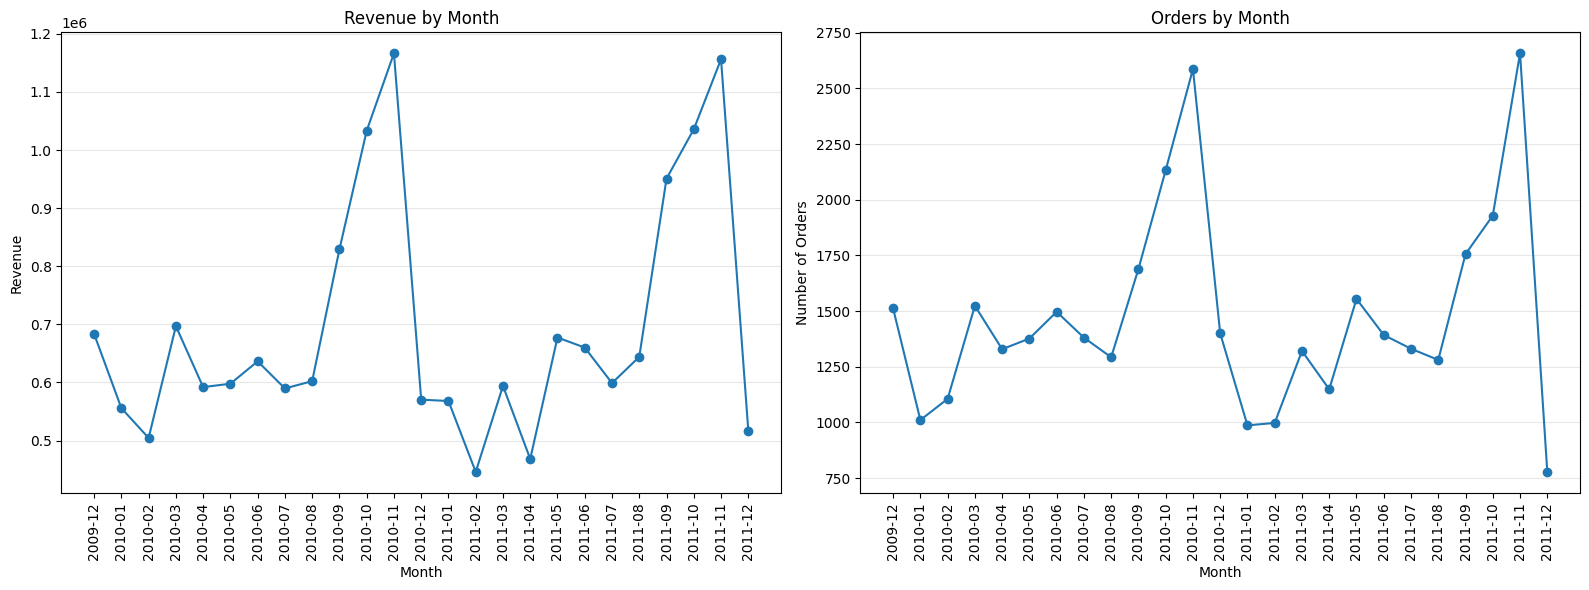

In [199]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Revenue
ax[0].plot(
    monthly_sales['InvoiceDate'].astype(str),
    monthly_sales['revenue'],
    marker='o'
)
ax[0].set_title('Revenue by Month')
ax[0].set_xlabel('Month')
ax[0].set_ylabel('Revenue')
ax[0].tick_params(axis='x', rotation=90)
ax[0].grid(axis="y", alpha=0.3)

# Orders
ax[1].plot(
    monthly_sales['InvoiceDate'].astype(str),
    monthly_sales['orders'],
    marker='o'
)
ax[1].set_title('Orders by Month')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Number of Orders')
ax[1].tick_params(axis='x', rotation=90)
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The dataset covers the period from December 1 2009 to December 9 2011, representing approximately 24.2 months of transaction data.

The final month (December 2011) is incomplete, as the dataset ends on December 9, 2011. Therefore, December 2011 should not be directly compared with full calendar months when interpreting order or revenue trends.

Monthly orders and revenue show a clear seasonal pattern, with sales activity increasing during the autumn months, in September–November.

The pattern is similar across 2010 and 2011, with November showing the highest order volumes in both years.


### Customer distribution

In [200]:
country_summary = (df_clean.groupby('Country')
  .agg(customers=('Customer ID', 'nunique'), orders=('Invoice', 'nunique'), revenue=('Revenue', 'sum'))
  .sort_values('revenue', ascending=False)
  .reset_index())
country_summary.head()

,Country,customers,orders,revenue
0,United Kingdom,5353,33546,1.438923e+07
1,EIRE,5,567,6.165705e+05
2,Netherlands,22,229,5.540381e+05
3,Germany,107,789,4.250197e+05
4,France,95,614,3.487690e+05


In [201]:
country_summary['revenue_share'] = (country_summary['revenue'] / country_summary['revenue'].sum()) * 100

country_summary['customer_share'] = (country_summary['customers'] / country_summary['customers'].sum()) * 100

country_summary.head(10)

,Country,customers,orders,revenue,revenue_share,customer_share
0,United Kingdom,5353,33546,1.438923e+07,82.816673,90.821174
1,EIRE,5,567,6.165705e+05,3.548647,0.084832
2,Netherlands,22,229,5.540381e+05,3.188744,0.373261
3,Germany,107,789,4.250197e+05,2.446184,1.815405
4,France,95,614,3.487690e+05,2.007326,1.611809
5,Australia,15,95,1.692835e+05,0.974304,0.254496
6,Spain,41,154,1.083325e+05,0.623503,0.695623
7,Switzerland,22,90,1.000619e+05,0.575903,0.373261
8,Sweden,19,104,9.151582e+04,0.526716,0.322362
9,Denmark,12,43,6.858069e+04,0.394713,0.203597


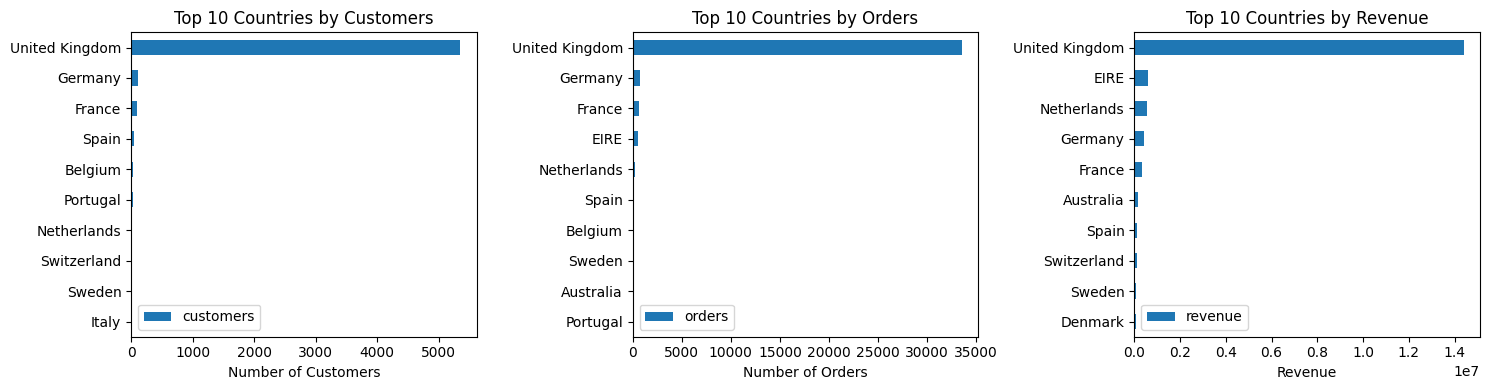

In [202]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Top 10 countries by customers
country_summary.sort_values('customers', ascending=False).head(10).plot(
    x='Country',
    y='customers',
    kind='barh',
    ax=ax[0]
)

ax[0].set_title('Top 10 Countries by Customers')
ax[0].set_xlabel('Number of Customers')
ax[0].set_ylabel('')
ax[0].invert_yaxis()

# Top 10 countries by orders
country_summary.sort_values('orders', ascending=False).head(10).plot(
    x='Country',
    y='orders',
    kind='barh',
    ax=ax[1]
)

ax[1].set_title('Top 10 Countries by Orders')
ax[1].set_xlabel('Number of Orders')
ax[1].set_ylabel('')
ax[1].invert_yaxis()

# Top 10 countries by revenue
country_summary.sort_values('revenue', ascending=False).head(10).plot(
    x='Country',
    y='revenue',
    kind='barh',
    ax=ax[2]
)

ax[2].set_title('Top 10 Countries by Revenue')
ax[2].set_xlabel('Revenue')
ax[2].set_ylabel('')
ax[2].invert_yaxis()

plt.tight_layout()
plt.show()

United Kingdom is the dominant market in the dataset, accounting for approximately 91% of customers, 33 546 orders and 83% of total revenue.

However, customer, order and revenue rankings differ substantially across the remaining countries.

For example, EIRE has only 5 customers but generates approximately 616K in revenue from 567 orders. The Netherlands shows a similar pattern, with only 22 customers generating approximately 554K from 229 orders.

This indicates that some countries have a much higher revenue and order volume per customer than others. This may suggest the presence of large customers, but this should be investigated further rather than assumed at this stage.

Although the United Kingdom is clearly the dominant market, several smaller markets show disproportionately high order and revenue volumes relative to their customer base.

We will therefore investigate customer-level purchasing behavior before deciding whether the final analysis should include all countries or focus on the United Kingdom.

### Customer purchase distribution



In [203]:
# orders per customer
orders_per_customer = df_clean.groupby('Customer ID')['Invoice'].nunique().sort_values(ascending=False)
orders_per_customer.describe()

,Invoice
count,5881.000000
mean,6.287196
std,13.012879
min,1.000000
25%,1.000000
50%,3.000000
75%,7.000000
max,398.000000


In [204]:
orders_per_customer.head(10)

,Invoice
Customer ID,
14911,398
12748,337
17841,211
15311,208
13089,203
14606,192
14156,156
17850,155
14646,152


The median customer places 3 orders, while the mean is 6.3 orders. The maximum is 398 orders for a single customer, indicating a small group of extremely frequent buyers.

This heavy-tailed pattern suggests that the dataset contains customers with substantially different purchasing behavior. Combined with the country-level analysis, where some countries generate disproportionately high revenue from a very small number of customers, this may indicate the presence of wholesale customers.


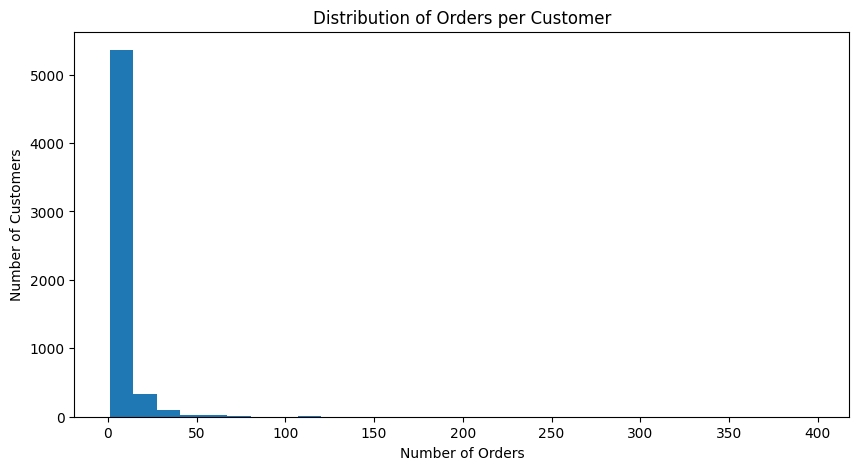

In [205]:
plt.figure(figsize=(10, 5))

plt.hist(orders_per_customer, bins=30)

plt.title('Distribution of Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.show()

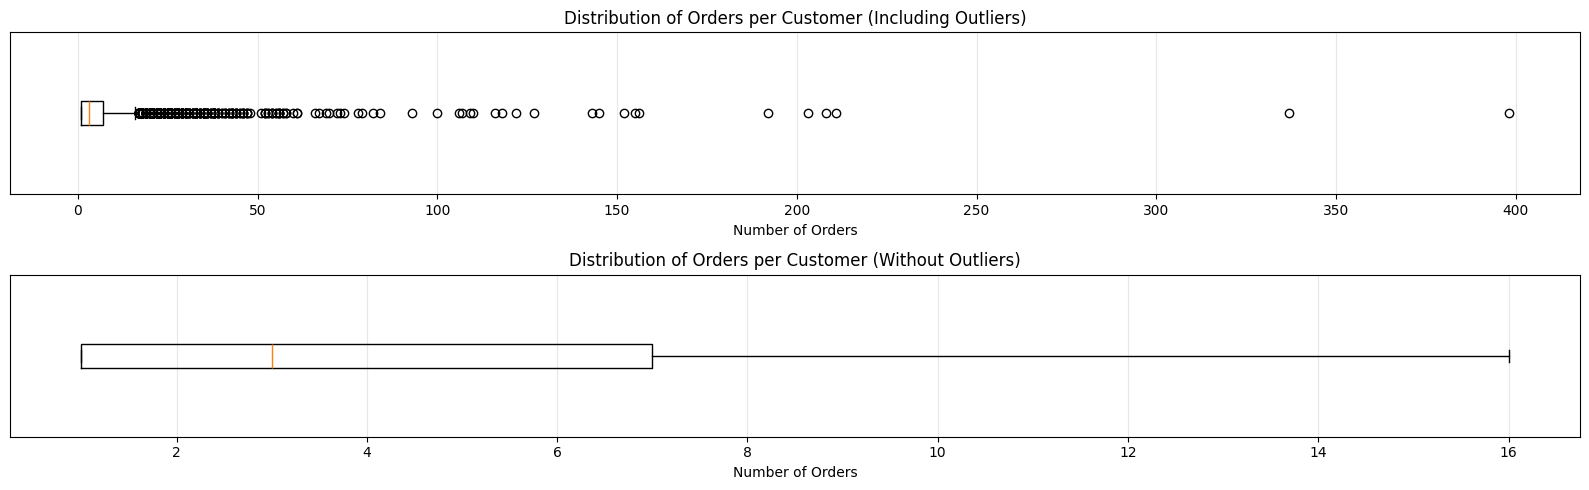

In [206]:
fig, ax = plt.subplots(2, 1, figsize=(16, 5))

ax[0].boxplot(orders_per_customer,vert=False)
ax[0].set_title("Distribution of Orders per Customer (Including Outliers)")
ax[0].set_xlabel("Number of Orders")
ax[0].grid(axis='x', alpha=0.3)
ax[0].set_yticks([])

ax[1].boxplot(orders_per_customer,vert=False, showfliers=False)
ax[1].set_title("Distribution of Orders per Customer (Without Outliers)")
ax[1].set_xlabel("Number of Orders")
ax[1].grid(axis='x', alpha=0.3)
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

Orders per customer are strongly right-skewed.

The median customer places 3 orders, while 75% of customers place 7 orders or fewer. At the same time, a small group of customers places substantially more orders, with the maximum reaching 398 orders.

The boxplot confirms a pronounced heavy tail, with many high-frequency customers identified as statistical outliers.

This pattern, together with the country-level revenue concentration observed above, suggests that the dataset may contain wholesale customers. This remains a hypothesis rather than a confirmed classification.

In [207]:
# revenue per customer
revenue_per_customer = df_clean.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
revenue_per_customer.describe()

,Revenue
count,5881.000000
mean,2954.396237
std,14437.322635
min,0.000000
25%,341.900000
50%,865.600000
75%,2247.720000
max,580987.040000


In [208]:
revenue_per_customer.head()

,Revenue
Customer ID,
18102,580987.04
14646,528602.52
14156,313437.62
14911,291420.81
17450,244784.25


The median customer generates 865.6 in revenue, while the mean is considerably higher at 2 954.4. The maximum customer revenue reaches approximately 581K.

The large difference between the median and mean, together with the very high maximum values, indicates that a relatively small group of customers generates a disproportionately large share of revenue.

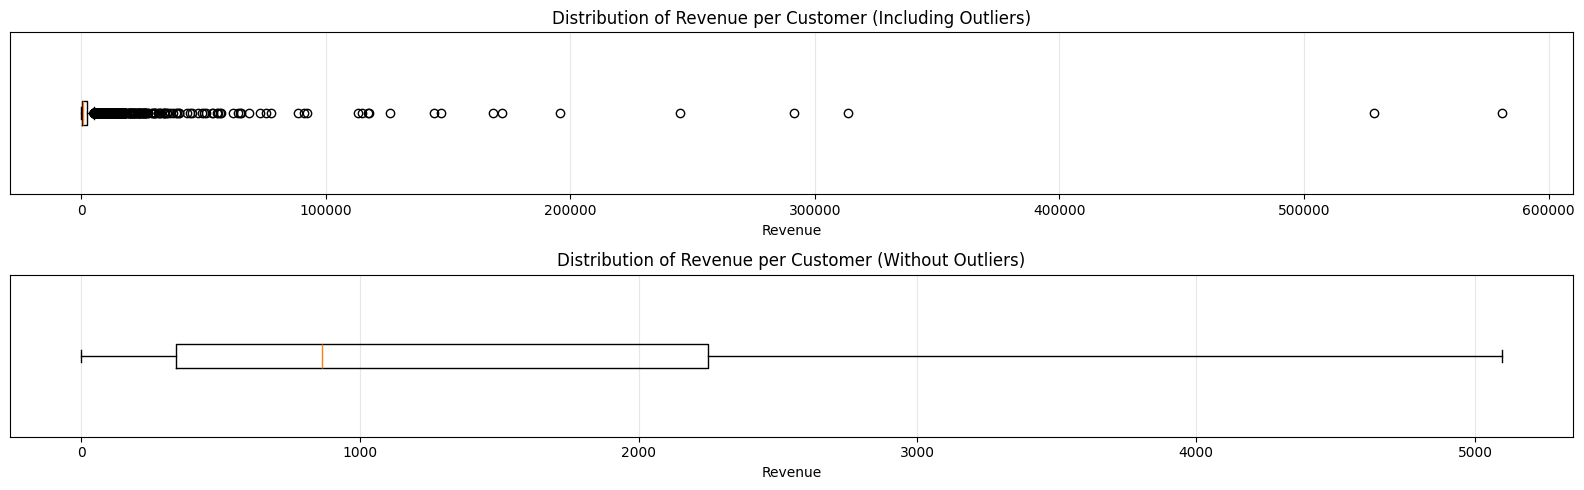

In [209]:
fig, ax = plt.subplots(2, 1, figsize=(16, 5))

ax[0].boxplot(revenue_per_customer,vert=False)
ax[0].set_title("Distribution of Revenue per Customer (Including Outliers)")
ax[0].set_xlabel("Revenue")
ax[0].grid(axis='x', alpha=0.3)
ax[0].set_yticks([])

ax[1].boxplot(revenue_per_customer,vert=False, showfliers=False)
ax[1].set_title("Distribution of Revenue per Customer (Without Outliers)")
ax[1].set_xlabel("Revenue")
ax[1].grid(axis='x', alpha=0.3)
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

Customer revenue is highly right-skewed.

Most customers generate relatively modest revenue, while a small number of customers account for exceptionally high revenue values, reaching up to approximately 581K per customer.

This indicates a strong concentration of revenue among a relatively small group of customers and substantial heterogeneity in customer value.

In [210]:
# average order value per customer
order_revenue = df_clean.groupby(['Customer ID', 'Invoice'])['Revenue'].sum()
order_revenue.head()

Customer ID  Invoice
12346        491725     45.0
             491742     22.5
             491744     22.5
             492718     22.5
             492722      1.0
Name: Revenue, dtype: float64

In [211]:
aov_per_customer = order_revenue.groupby('Customer ID').mean().sort_values(ascending = False)
aov_per_customer.describe()

,Revenue
count,5881.000000
mean,384.975880
std,1213.998407
min,0.000000
25%,176.627143
50%,279.129091
75%,414.895714
max,84236.250000


In [212]:
aov_per_customer.head()

,Revenue
Customer ID,
16446,84236.250000
15749,14844.766667
15098,13305.500000
13687,11880.840000
12918,10953.500000


The median AOV per customer is 279.13, while the mean is 384.98. The maximum average order value reaches approximately 84K, indicating a small group of customers with exceptionally high average order values.

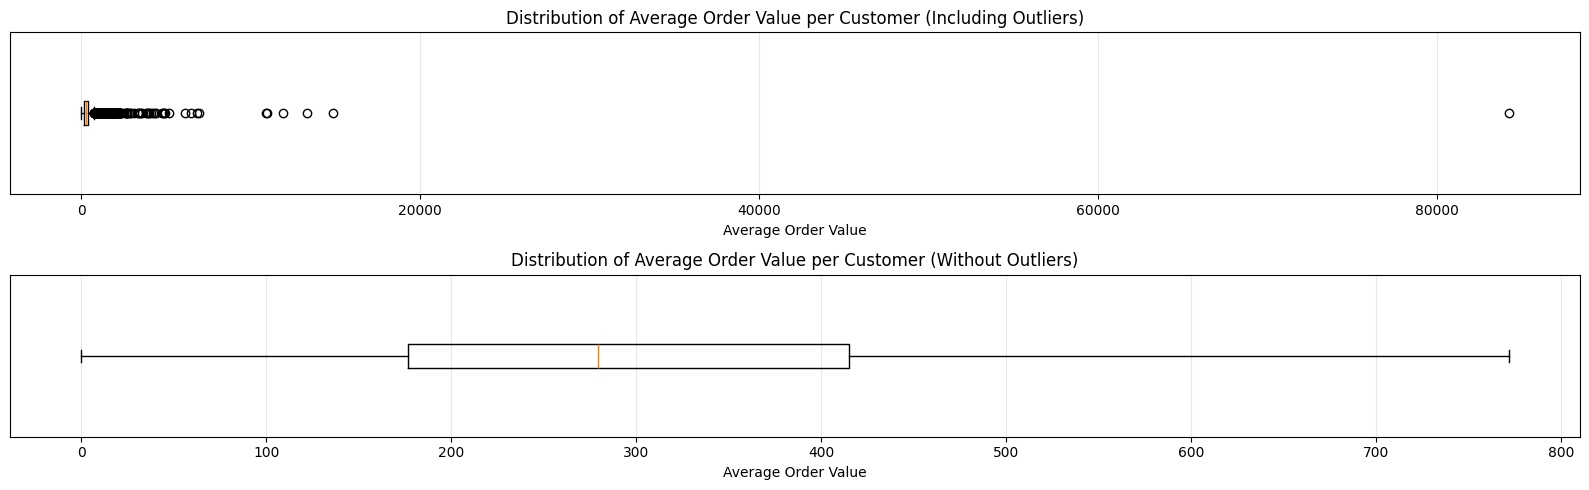

In [213]:
fig, ax = plt.subplots(2, 1, figsize=(16, 5))

ax[0].boxplot(aov_per_customer,vert=False)
ax[0].set_title("Distribution of Average Order Value per Customer (Including Outliers)")
ax[0].set_xlabel("Average Order Value")
ax[0].grid(axis='x', alpha=0.3)
ax[0].set_yticks([])

ax[1].boxplot(aov_per_customer,vert=False, showfliers=False)
ax[1].set_title("Distribution of Average Order Value per Customer (Without Outliers)")
ax[1].set_xlabel("Average Order Value")
ax[1].grid(axis='x', alpha=0.3)
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

AOV is highly right-skewed, with a small group of customers showing exceptionally high average order values.

---

Taken together, these patterns indicate substantial variation in customer purchasing behavior and value, with a relatively small group of high-frequency and high-value customers contributing disproportionately to the dataset.

The observed purchasing patterns may indicate the presence of wholesale.

## Customer Purchase History

In [214]:
customer_history = df_clean.groupby('Customer ID').agg(
        first_purchase_date=('InvoiceDate', 'min'),
        last_purchase_date=('InvoiceDate', 'max'),
        number_of_orders=('Invoice', 'nunique'),
        number_of_items=('Quantity', 'sum'),
        total_revenue=('Revenue', 'sum'))

customer_history['average_order_value'] = customer_history['total_revenue'] / customer_history['number_of_orders']

customer_history.head()

,first_purchase_date,last_purchase_date,number_of_orders,number_of_items,total_revenue,average_order_value
Customer ID,,,,,,
12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,74285,77556.46,6463.038333
12347,2010-10-31 14:20:00,2011-12-07 15:52:00,8,2967,4921.53,615.191250
12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2714,2019.40,403.880000
12349,2010-04-29 13:20:00,2011-11-21 09:51:00,4,1624,4428.69,1107.172500
12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,334.400000


In [215]:
customer_history.describe()

,first_purchase_date,last_purchase_date,number_of_orders,number_of_items,total_revenue,average_order_value
count,5881,5881,5881.000000,5881.000000,5881.000000,5881.000000
mean,2010-08-22 07:16:55.031457280,2011-05-22 13:18:31.749702400,6.287196,1790.291617,2954.396237,384.975880
min,2009-12-01 07:45:00,2009-12-01 09:55:00,1.000000,1.000000,0.000000,0.000000
25%,2010-02-09 14:17:00,2010-11-25 10:11:00,1.000000,186.000000,341.900000,176.627143
50%,2010-06-27 13:29:00,2011-09-05 11:52:00,3.000000,480.000000,865.600000,279.129091
75%,2011-01-30 14:36:00,2011-11-14 11:33:00,7.000000,1350.000000,2247.720000,414.895714
max,2011-12-09 12:16:00,2011-12-09 12:50:00,398.000000,367833.000000,580987.040000,84236.250000
std,NaN,NaN,13.012879,8882.005013,14437.322635,1213.998407


The customer-level purchase history shows substantial heterogeneity in customer behavior.

The median customer places 3 orders, while 75% of customers place 7 orders or fewer. At the same time, a small number of customers place exceptionally large numbers of orders, with the maximum reaching 398.

The same pattern is observed for the number of items and total revenue. The median customer generates $865.60 in total revenue, compared with a mean of 2 954.40, while the maximum customer revenue exceeds 580K. Average order value is also highly right-skewed, with a median of 279.13 and a maximum exceeding 84K.

These results indicate that the customer base is highly heterogeneous. In particular, the presence of customers with extremely high purchase frequency, order volume, and revenue suggests that the dataset may contain different purchasing behaviors, potentially including wholesale customers.

## Customer Type: Retail vs Wholesale

The EDA and customer-level analysis revealed a small group of customers with exceptionally high purchase frequency, item volume, and revenue. These patterns may reflect wholesale purchasing rather than typical retail behavior.

Therefore, instead of removing these customers as outliers, we will investigate their order-level purchasing behavior and determine whether the data supports separating customers into Retail and Wholesale segments.

The classification will be based on purchasing behavior rather than revenue alone.

### Searching threshold

In [216]:
invoice_history = (df_clean.groupby(['Customer ID', 'Invoice']).agg(
    items_per_invoice=('Quantity', 'sum'),
    unique_stockcodes_per_invoice=('StockCode', 'nunique')).reset_index())

invoice_history.head(15)

,Customer ID,Invoice,items_per_invoice,unique_stockcodes_per_invoice
0,12346,491725,10,1
1,12346,491742,5,1
2,12346,491744,5,1
3,12346,492718,5,1
4,12346,492722,1,1
5,12346,493410,5,1
6,12346,493412,5,1
7,12346,494450,5,1
8,12346,495295,5,1
9,12346,499763,5,5


In [217]:
customer_behavior = (invoice_history.groupby('Customer ID').agg(
    avg_items_per_invoice=('items_per_invoice', 'mean'),
    avg_unique_stockcodes_per_invoice=('unique_stockcodes_per_invoice', 'mean')))

customer_behavior.head()

,avg_items_per_invoice,avg_unique_stockcodes_per_invoice
Customer ID,,
12346,6190.416667,2.833333
12347,370.875000,27.750000
12348,542.800000,9.400000
12349,406.000000,43.750000
12350,197.000000,17.000000


In [218]:
customer_behavior.describe()

,avg_items_per_invoice,avg_unique_stockcodes_per_invoice
count,5881.000000,5881.000000
mean,249.569083,21.051388
std,1433.120455,17.867078
min,1.000000,1.000000
25%,90.952381,9.625000
50%,153.500000,17.000000
75%,257.000000,27.000000
max,87167.000000,298.823529


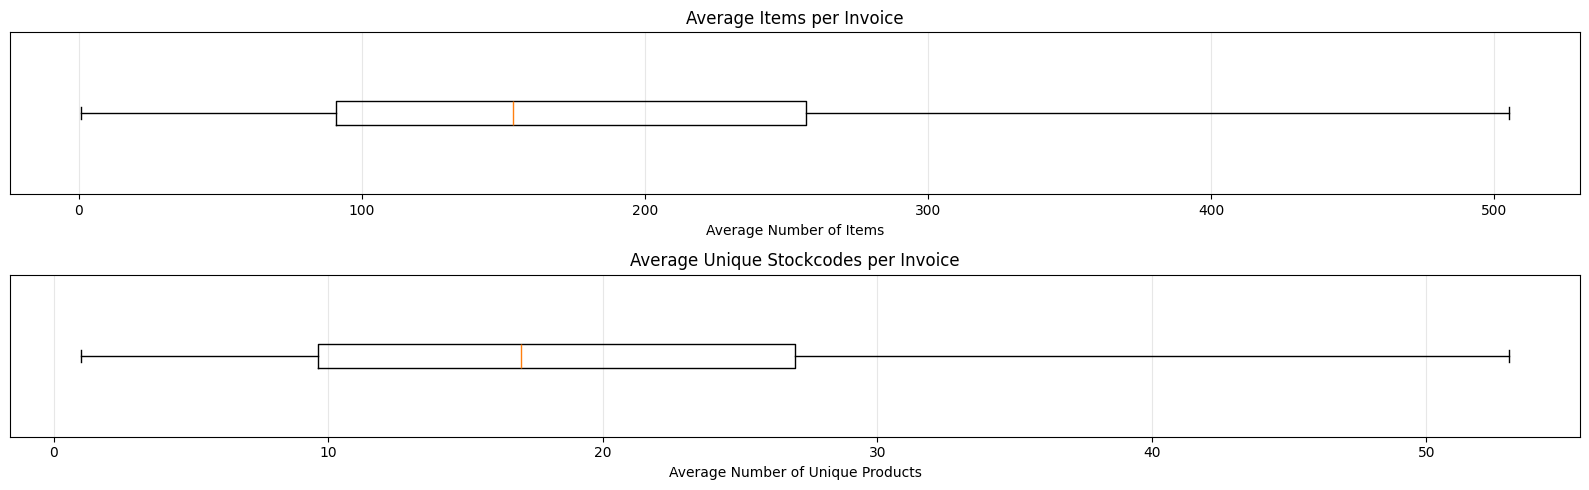

In [219]:
fig, ax = plt.subplots(2, 1, figsize=(16, 5))

ax[0].boxplot(customer_behavior['avg_items_per_invoice'],vert=False, showfliers=False)
ax[0].set_title("Average Items per Invoice")
ax[0].set_xlabel("Average Number of Items")
ax[0].grid(axis='x', alpha=0.3)
ax[0].set_yticks([])

ax[1].boxplot(customer_behavior['avg_unique_stockcodes_per_invoice'],vert=False, showfliers=False)
ax[1].set_title("Average Unique Stockcodes per Invoice")
ax[1].set_xlabel("Average Number of Unique Products")
ax[1].grid(axis='x', alpha=0.3)
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

The distributions of both behavioral indicators are strongly right-skewed. Boxplot-based thresholds were used to identify customers with unusually high purchase volume or product assortment. These thresholds will be used to investigate potential wholesale customers rather than to classify them automatically.

In [220]:
# items per invoice
q1_items = customer_behavior['avg_items_per_invoice'].quantile(0.25)
q3_items = customer_behavior['avg_items_per_invoice'].quantile(0.75)

iqr_items = q3_items - q1_items
items_threshold = q3_items + 1.5 * iqr_items

print(f"Q1: {q1_items:.2f}")
print(f"Q3: {q3_items:.2f}")
print(f"IQR: {iqr_items:.2f}")
print(f"Upper threshold: {items_threshold:.2f} items/invoice")

Q1: 90.95
Q3: 257.00
IQR: 166.05
Upper threshold: 506.07 items/invoice


In [221]:
# unique codes per inoice
q1_stock = customer_behavior['avg_unique_stockcodes_per_invoice'].quantile(0.25)
q3_stock = customer_behavior['avg_unique_stockcodes_per_invoice'].quantile(0.75)

iqr_stock = q3_stock - q1_stock
stock_threshold = q3_stock + 1.5 * iqr_stock

print(f"Q1: {q1_stock:.2f}")
print(f"Q3: {q3_stock:.2f}")
print(f"IQR: {iqr_stock:.2f}")
print(f"Upper threshold: {stock_threshold:.2f} unique products/invoice")

Q1: 9.62
Q3: 27.00
IQR: 17.38
Upper threshold: 53.06 unique products/invoice


In [222]:
items_outliers = customer_behavior[customer_behavior['avg_items_per_invoice'] > items_threshold]

stock_outliers = customer_behavior[customer_behavior['avg_unique_stockcodes_per_invoice'] > stock_threshold]

print(f"Above items threshold: {len(items_outliers)} customers")
print(f"Share: {len(items_outliers) / len(customer_behavior):.2%}")

print(f"\nAbove stockcodes threshold: {len(stock_outliers)} customers")
print(f"Share: {len(stock_outliers) / len(customer_behavior):.2%}")

Above items threshold: 360 customers
Share: 6.12%

Above stockcodes threshold: 309 customers
Share: 5.25%


In [223]:
wholesale_candidates = customer_behavior[
    (customer_behavior['avg_items_per_invoice'] > items_threshold) |
    (customer_behavior['avg_unique_stockcodes_per_invoice'] > stock_threshold)]

print(f"Wholesale candidates: {len(wholesale_candidates)}")
print(f"Share: {len(wholesale_candidates) / len(customer_behavior):.2%}")

Wholesale candidates: 587
Share: 9.98%


In [224]:
both_outliers = customer_behavior[
    (customer_behavior['avg_items_per_invoice'] > items_threshold) &
    (customer_behavior['avg_unique_stockcodes_per_invoice'] > stock_threshold)]

print(f"Above both thresholds: {len(both_outliers)} customers")
print(f"Share: {len(both_outliers) / len(customer_behavior):.2%}")

Above both thresholds: 82 customers
Share: 1.39%


Customer purchasing behavior shows a strongly right-skewed distribution of both average items per invoice and average number of unique products per invoice. This indicates that a subset of customers places substantially larger and/or more diverse orders than the majority.

Based on the IQR-based thresholds derived from the distributions, 360 customers exceed the volume threshold and 309 exceed the product-diversity threshold. In total, 587 customers exceed at least one of the two thresholds, while 82 exceed both.

These results suggest that wholesale behavior may manifest in different ways: some customers may purchase very large quantities of a limited number of products, while others may place large and diverse orders. Therefore, both indicators should be considered when identifying potential wholesale customers, rather than requiring a customer to exceed both thresholds.

### Customer Segmentation

In [225]:
# join tables
customer_segments = customer_history.join(customer_behavior[['avg_items_per_invoice', 'avg_unique_stockcodes_per_invoice']], how='inner')
customer_segments.head()

,first_purchase_date,last_purchase_date,number_of_orders,number_of_items,total_revenue,average_order_value,avg_items_per_invoice,avg_unique_stockcodes_per_invoice
Customer ID,,,,,,,,
12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,74285,77556.46,6463.038333,6190.416667,2.833333
12347,2010-10-31 14:20:00,2011-12-07 15:52:00,8,2967,4921.53,615.191250,370.875000,27.750000
12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2714,2019.40,403.880000,542.800000,9.400000
12349,2010-04-29 13:20:00,2011-11-21 09:51:00,4,1624,4428.69,1107.172500,406.000000,43.750000
12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,334.400000,197.000000,17.000000


In [226]:
# create segment
customer_segments['customer_type'] = 'Retail'

customer_segments.loc[
    (customer_segments['avg_items_per_invoice'] > items_threshold) |
    (customer_segments['avg_unique_stockcodes_per_invoice'] > stock_threshold), 'customer_type'] = 'Wholesale'

customer_segments.head()

,first_purchase_date,last_purchase_date,number_of_orders,number_of_items,total_revenue,average_order_value,avg_items_per_invoice,avg_unique_stockcodes_per_invoice,customer_type
Customer ID,,,,,,,,,
12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,74285,77556.46,6463.038333,6190.416667,2.833333,Wholesale
12347,2010-10-31 14:20:00,2011-12-07 15:52:00,8,2967,4921.53,615.191250,370.875000,27.750000,Retail
12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2714,2019.40,403.880000,542.800000,9.400000,Wholesale
12349,2010-04-29 13:20:00,2011-11-21 09:51:00,4,1624,4428.69,1107.172500,406.000000,43.750000,Retail
12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,334.400000,197.000000,17.000000,Retail


In [227]:
customer_segments['customer_type'].value_counts()

,count
customer_type,
Retail,5294
Wholesale,587


In [228]:
customer_segments.groupby('customer_type')[
    ['number_of_orders',
     'number_of_items',
     'total_revenue',
     'average_order_value']].agg(['count', 'median', 'mean'])

number_of_orders                  number_of_items          \
                         count median      mean           count  median   
customer_type                                                             
Retail                    5294    3.0  6.108802            5294   420.0   
Wholesale                  587    3.0  7.896082             587  1394.0   

                           total_revenue                         \
                      mean         count   median          mean   
customer_type                                                     
Retail         1156.996033          5294   782.66   2121.860396   
Wholesale      7501.819421           587  1793.06  10462.819990   

              average_order_value                           
                            count      median         mean  
customer_type                                               
Retail                       5294  259.445500   303.733784  
Wholesale                     587  649.403333  1117.677168

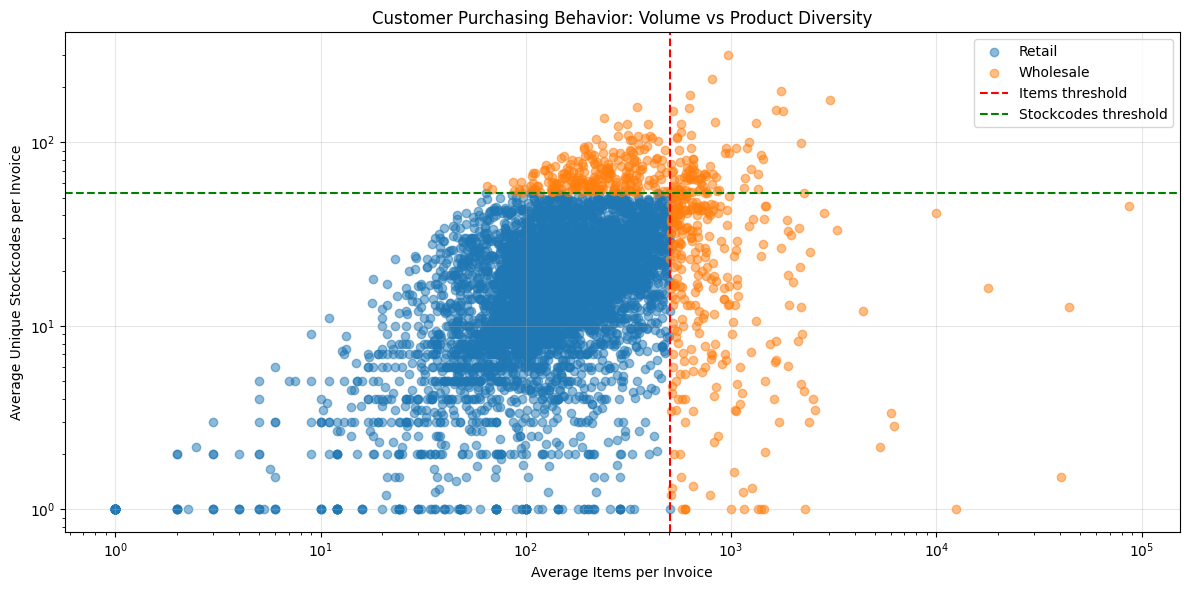

In [229]:
plt.figure(figsize=(12, 6))

for customer_type, group in customer_segments.groupby('customer_type'):
    plt.scatter(
        group['avg_items_per_invoice'],
        group['avg_unique_stockcodes_per_invoice'],
        label=customer_type,
        alpha=0.5
    )

plt.xscale('log')
plt.yscale('log')

plt.axvline(items_threshold, linestyle='--', label='Items threshold', color='red')
plt.axhline(stock_threshold, linestyle='--', label='Stockcodes threshold', color='green')

plt.xlabel('Average Items per Invoice')
plt.ylabel('Average Unique Stockcodes per Invoice')
plt.title('Customer Purchasing Behavior: Volume vs Product Diversity')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The IQR-based thresholds of 506 items per invoice and 53 unique stockcodes per invoice identify a distinct group of high-volume customers. However, the scatter plot shows some overlap between the groups, indicating that wholesale behavior is not perfectly separated from retail behavior.

Therefore, we use the thresholds as a behavior-based operational definition of Wholesale customers, rather than treating Wholesale and Retail as naturally separated populations.

### Retail vs Wholesale Comparison

In [230]:
customer_segments.reset_index()

segment_comparison = (customer_segments.groupby('customer_type').agg(
        customers=('customer_type', 'size'),
        orders=('number_of_orders', 'sum'),
        items=('number_of_items', 'sum'),
        total_revenue=('total_revenue', 'sum'),
        average_order_value=('average_order_value', 'median')))

segment_comparison['revenue_share'] = round((segment_comparison['total_revenue'] / segment_comparison['total_revenue'].sum() * 100),2)

segment_comparison


,customers,orders,items,total_revenue,average_order_value,revenue_share
customer_type,,,,,,
Retail,5294,32340,6125137,1.123313e+07,259.445500,64.65
Wholesale,587,4635,4403568,6.141675e+06,649.403333,35.35


Wholesale customers represent only 10% of the customer base, but contribute 35.4% of total revenue. Their median average order value is approximately 2.5x higher than that of Retail customers (649 vs 259).

This confirms that the identified Wholesale segment has substantially different purchasing behavior and economic value. At the same time, Retail customers remain the dominant segment, accounting for 64.7% of total revenue.

Therefore, the customer base should be analyzed as two distinct behavioral segments. Cohort, retention and RFM analysis will focus primarily on Retail customers, while Wholesale customers will be analyzed separately as a smaller but high-value segment.

## Cohort Analysis

### Define cohort

In [231]:
retail_customers = customer_segments.index[customer_segments['customer_type'] == 'Retail']
df_retail = df_clean[df_clean['Customer ID'].isin(retail_customers)].copy()

df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [232]:
df_retail['PurchaseMonth'] = (df_retail['InvoiceDate'].dt.to_period('M'))
cohort_month = (df_retail.groupby('Customer ID')['PurchaseMonth'].min().rename('CohortMonth'))
cohort_month.head()

,CohortMonth
Customer ID,
12347,2010-10
12349,2010-04
12350,2011-02
12351,2010-11
12352,2010-11


In [233]:
df_retail = df_retail.join(cohort_month, on ='Customer ID')

df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,PurchaseMonth,CohortMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,2009-12


### Customer retention

In [234]:
df_retail['MonthSinceFirstPurchase'] = (
    (df_retail['PurchaseMonth'].dt.year - df_retail['CohortMonth'].dt.year) * 12
    + (df_retail['PurchaseMonth'].dt.month - df_retail['CohortMonth'].dt.month))
df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,PurchaseMonth,CohortMonth,MonthSinceFirstPurchase
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,2009-12,0


In [235]:
cohort_retention = df_retail.groupby(['CohortMonth', 'MonthSinceFirstPurchase'])['Customer ID'].nunique().reset_index(name='retained_customers')

cohort_retention.head()

,CohortMonth,MonthSinceFirstPurchase,retained_customers
0,2009-12,0,864
1,2009-12,1,302
2,2009-12,2,280
3,2009-12,3,356
4,2009-12,4,326


In [236]:
# 'first' take the Month 0 customer count as the initial cohort size
cohort_retention['cohort_size'] = cohort_retention.groupby('CohortMonth')['retained_customers'].transform('first')

cohort_retention['retention_rate'] = round(cohort_retention['retained_customers'] / cohort_retention['cohort_size'] * 100, 2)

cohort_retention.head()

,CohortMonth,MonthSinceFirstPurchase,retained_customers,cohort_size,retention_rate
0,2009-12,0,864,864,100.00
1,2009-12,1,302,864,34.95
2,2009-12,2,280,864,32.41
3,2009-12,3,356,864,41.20
4,2009-12,4,326,864,37.73


### Customer retention heatmap

In [237]:
retention_matrix = cohort_retention.pivot(index='CohortMonth', columns='MonthSinceFirstPurchase', values='retention_rate')
retention_matrix.head()

MonthSinceFirstPurchase,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,34.95,32.41,41.20,37.73,35.53,36.23,34.26,33.33,35.53,...,28.59,25.69,29.51,28.12,25.23,25.23,30.67,29.75,40.05,19.33
2010-01,100.0,19.20,30.95,29.80,26.36,30.66,25.79,22.64,28.37,30.95,...,15.47,23.21,20.06,16.33,19.20,24.36,19.20,23.50,5.73,NaN
2010-02,100.0,23.39,22.51,28.36,24.56,18.71,19.30,28.95,24.27,26.90,...,20.47,15.79,15.20,13.74,23.39,23.68,15.79,5.56,NaN,NaN
2010-03,100.0,18.88,22.19,23.72,22.45,18.62,24.74,29.59,27.04,10.97,...,16.33,16.33,14.80,15.82,19.90,20.15,7.91,NaN,NaN,NaN
2010-04,100.0,19.78,20.90,16.79,18.66,22.76,28.73,26.87,10.45,10.45,...,16.04,14.18,15.67,17.91,22.39,6.34,NaN,NaN,NaN,NaN


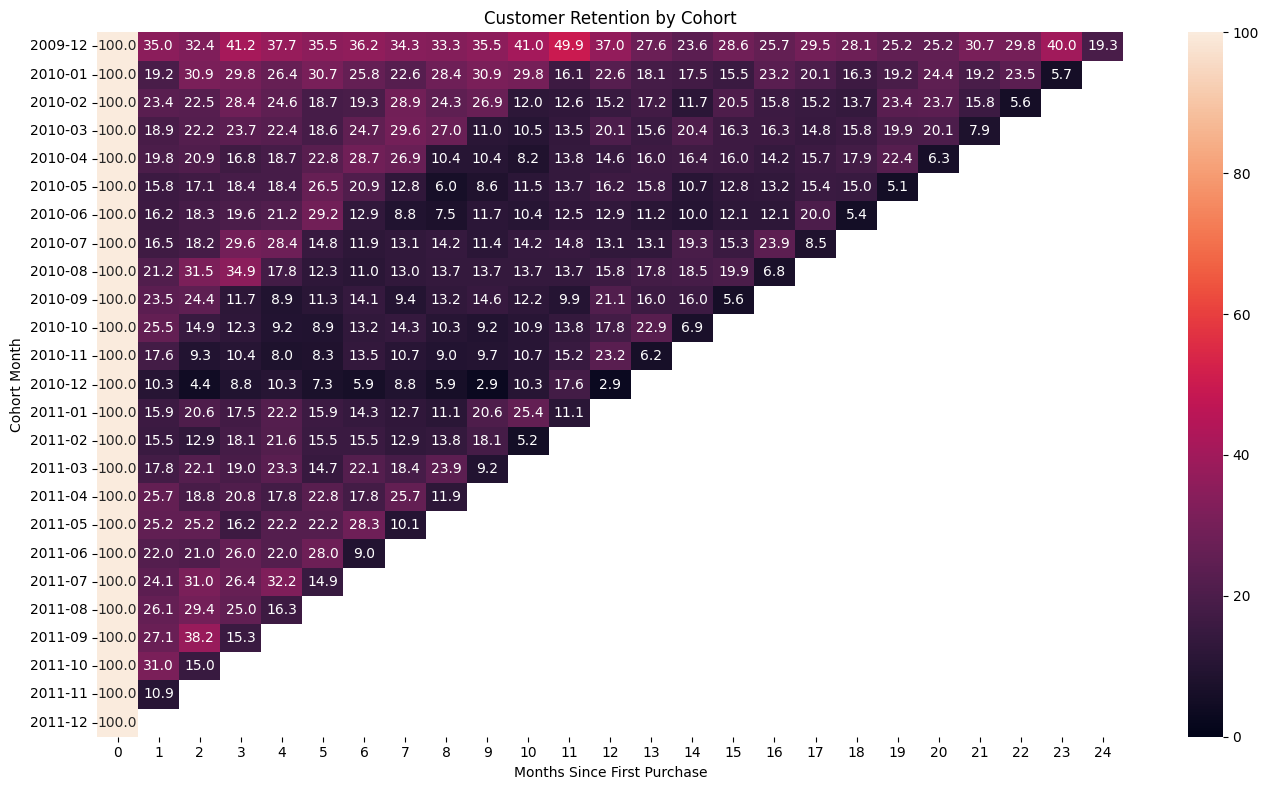

In [238]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".1f",
    vmin=0,
    vmax=100
)

plt.title("Customer Retention by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.show()

Cohort analysis allows us to evaluate how consistently customers return after their first purchase. Customers are grouped by the month of their first purchase, and retention is calculated as the percentage of customers from each cohort who made another purchase in subsequent months.

The heatmap shows substantial variation in retention across cohorts. While some cohorts maintain relatively stable retention over time, others experience a sharp decline shortly after the first purchase. For example, the December 2010 cohort shows particularly weak early retention, falling below 10% in several of the first months.

Later cohorts contain NaN values for months that cannot be observed because the dataset ends before enough time has elapsed.

### Revenue retention heatmap

In [239]:
cohort_revenue = (df_retail.groupby(['CohortMonth', 'MonthSinceFirstPurchase'])['Revenue'].sum().reset_index(name='revenue'))

cohort_revenue.head()

,CohortMonth,MonthSinceFirstPurchase,revenue
0,2009-12,0,466236.230
1,2009-12,1,189536.850
2,2009-12,2,167989.282
3,2009-12,3,212595.870
4,2009-12,4,198643.950


In [240]:
# 'first' take the Month 0 customer count as the initial cohort size
cohort_revenue['cohort_revenue'] = cohort_revenue.groupby('CohortMonth')['revenue'].transform('first')

cohort_revenue['revenue_retention_rate'] = round(cohort_revenue['revenue'] / cohort_revenue['cohort_revenue'] * 100, 2)

cohort_revenue.head()

,CohortMonth,MonthSinceFirstPurchase,revenue,cohort_revenue,revenue_retention_rate
0,2009-12,0,466236.230,466236.23,100.00
1,2009-12,1,189536.850,466236.23,40.65
2,2009-12,2,167989.282,466236.23,36.03
3,2009-12,3,212595.870,466236.23,45.60
4,2009-12,4,198643.950,466236.23,42.61


In [241]:
revenue_retention_matrix = cohort_revenue.pivot(index='CohortMonth', columns='MonthSinceFirstPurchase', values='revenue_retention_rate')
revenue_retention_matrix.head()

MonthSinceFirstPurchase,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,40.65,36.03,45.60,42.61,40.77,39.87,39.18,37.21,52.07,...,30.27,24.54,35.12,30.34,29.12,29.62,43.43,41.93,64.89,22.81
2010-01,100.0,18.67,33.42,35.79,34.01,41.85,29.93,30.15,40.21,40.89,...,18.14,28.89,24.25,22.73,25.65,35.47,31.56,37.16,6.41,NaN
2010-02,100.0,22.01,25.29,31.67,28.37,21.76,25.43,35.45,32.77,35.56,...,28.28,18.97,16.96,17.22,32.72,31.87,24.42,6.92,NaN,NaN
2010-03,100.0,17.72,17.23,22.19,18.03,20.87,24.65,32.83,28.81,8.82,...,13.20,17.23,15.98,15.69,23.71,21.38,6.97,NaN,NaN,NaN
2010-04,100.0,14.88,18.17,25.38,18.12,23.83,31.32,27.58,8.21,11.66,...,17.12,14.24,17.57,20.88,24.41,4.71,NaN,NaN,NaN,NaN


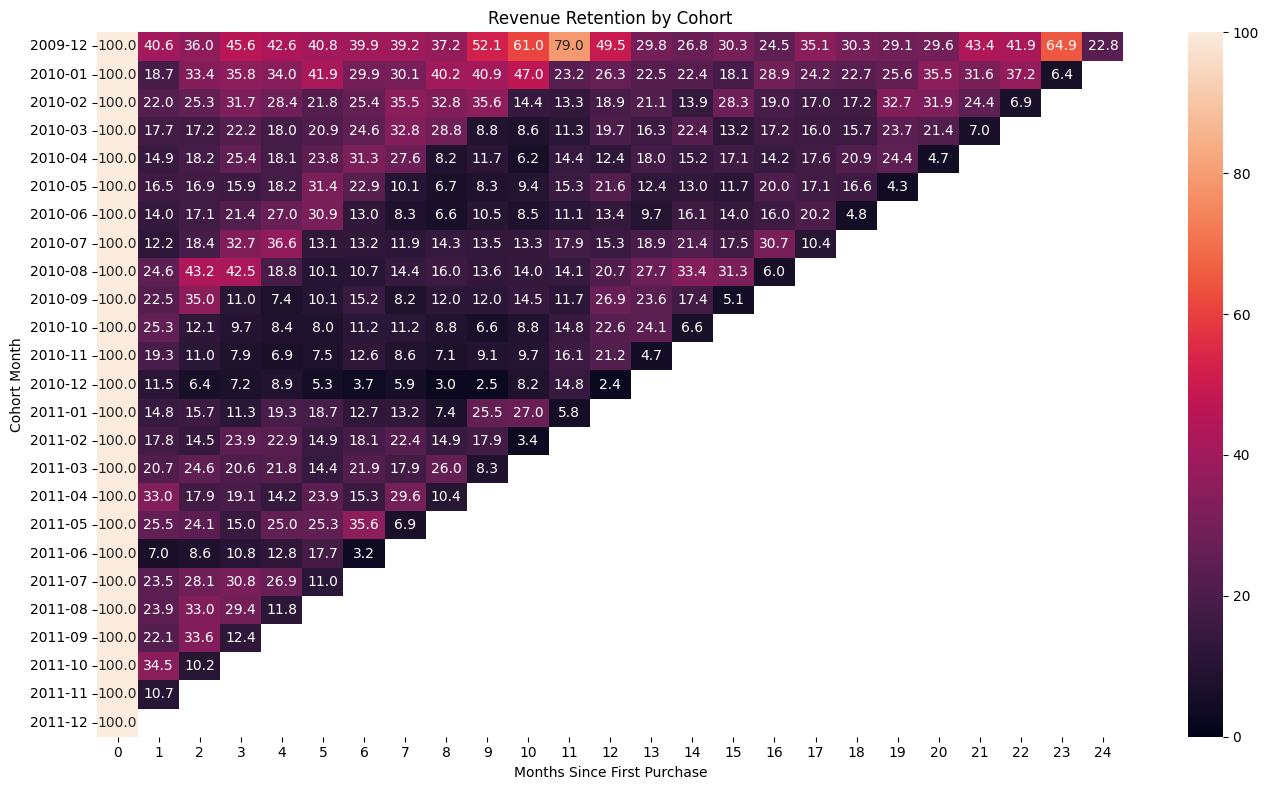

In [242]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    revenue_retention_matrix,
    annot=True,
    fmt=".1f",
    vmin=0,
    vmax=100
)

plt.title("Revenue Retention by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.tight_layout()
plt.show()

Revenue retention shows how much revenue each customer cohort continues to generate over time relative to its first purchase month. The results vary considerably across cohorts. Some cohorts maintain a relatively high share of their initial revenue for several months, while others experience a sharp decline shortly after acquisition.

The December 2010 cohort stands out as one of the weaker cohorts, with revenue retention falling to very low levels within the first year. In contrast, the December 2009 cohort demonstrates substantially stronger revenue retention and several periods of revenue recovery.

## New vs Returning Customers

In [243]:
df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,PurchaseMonth,CohortMonth,MonthSinceFirstPurchase
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,2009-12,0


In [244]:
# active months for customers
customer_months = df_retail[['Customer ID', 'PurchaseMonth', 'CohortMonth']].drop_duplicates()

customer_months.head()

,Customer ID,PurchaseMonth,CohortMonth
0,13085,2009-12,2009-12
12,13078,2009-12,2009-12
31,15362,2009-12,2009-12
71,12682,2009-12,2009-12
90,18087,2009-12,2009-12


In [245]:
customer_months['customer_status'] = np.where(customer_months['PurchaseMonth'] == customer_months['CohortMonth'], 'New', 'Returning')
customer_months.head()

,Customer ID,PurchaseMonth,CohortMonth,customer_status
0,13085,2009-12,2009-12,New
12,13078,2009-12,2009-12,New
31,15362,2009-12,2009-12,New
71,12682,2009-12,2009-12,New
90,18087,2009-12,2009-12,New


In [246]:
customer_months['customer_status'].value_counts()

,count
customer_status,
Returning,17633
New,5294


In [247]:
new_returning_monthly = customer_months.groupby(['PurchaseMonth', 'customer_status'])['Customer ID'].nunique().unstack(fill_value=0).reset_index()

new_returning_monthly.head()

customer_status,PurchaseMonth,New,Returning
0,2009-12,864,0
1,2010-01,349,302
2,2010-02,342,347
3,2010-03,392,544
4,2010-04,268,581


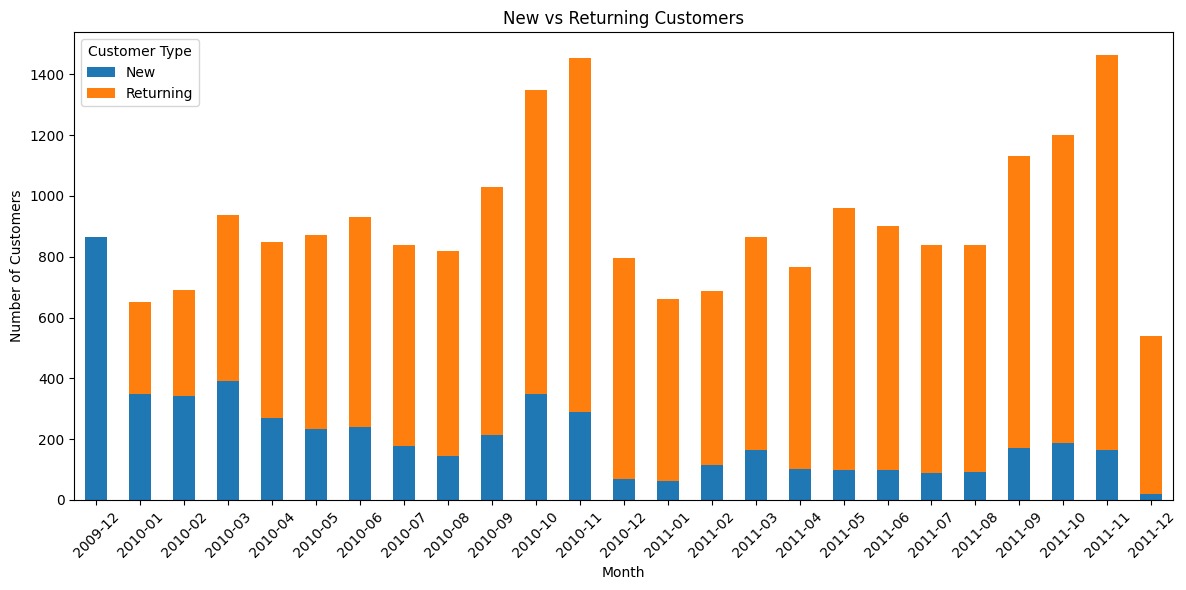

In [248]:
new_returning_monthly.plot(
    x='PurchaseMonth',
    y=['New', 'Returning'],
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('New vs Returning Customers')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Customer Type')

plt.tight_layout()
plt.show()

Customer activity is increasingly driven by returning customers rather than new customer acquisition. While new customers continue to join each month, returning customers become the dominant share of the active customer base after the first few months. This suggests that repeat purchases play an important role in sustaining customer activity and overall business growth.

## Churn Analysis

### Purchase interval analysis & Define churn threshold

In [249]:
# customers purchases table
customer_purchases = (df_retail[['Customer ID', 'Invoice', 'InvoiceDate']].drop_duplicates().sort_values(['Customer ID', 'InvoiceDate']))

customer_purchases.head()

,Customer ID,Invoice,InvoiceDate
423892,12347,529924,2010-10-31 14:20:00
517876,12347,537626,2010-12-07 14:57:00
597707,12347,542237,2011-01-26 14:30:00
673746,12347,549222,2011-04-07 10:43:00
746033,12347,556201,2011-06-09 13:01:00


In [250]:
customer_purchases['days_between_purchases'] = customer_purchases.groupby('Customer ID')['InvoiceDate'].diff().dt.days

customer_purchases.head()

,Customer ID,Invoice,InvoiceDate,days_between_purchases
423892,12347,529924,2010-10-31 14:20:00,NaN
517876,12347,537626,2010-12-07 14:57:00,37.0
597707,12347,542237,2011-01-26 14:30:00,49.0
673746,12347,549222,2011-04-07 10:43:00,70.0
746033,12347,556201,2011-06-09 13:01:00,63.0


In [251]:
# purchases from customers with > 2 purchases
purchase_intervals = customer_purchases[customer_purchases['days_between_purchases'].notna()].copy()
purchase_intervals['days_between_purchases'].describe()

,days_between_purchases
count,27100.000000
mean,52.814244
std,76.359511
min,0.000000
25%,7.000000
50%,26.000000
75%,63.000000
max,714.000000


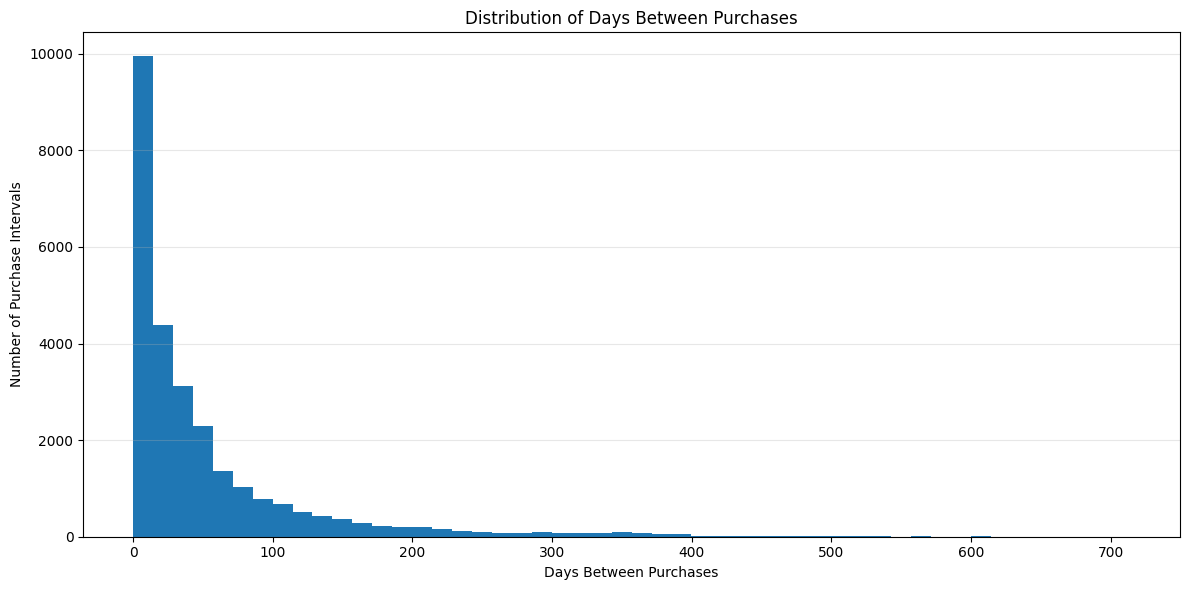

In [252]:
plt.figure(figsize=(12, 6))

plt.hist(purchase_intervals['days_between_purchases'], bins=50)

plt.title('Distribution of Days Between Purchases')
plt.xlabel('Days Between Purchases')
plt.ylabel('Number of Purchase Intervals')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [253]:
print(f"Median: {purchase_intervals['days_between_purchases'].median()} days")
print(f"75th percentile: {purchase_intervals['days_between_purchases'].quantile(0.75)} days")
print(f"90th percentile: {purchase_intervals['days_between_purchases'].quantile(0.9):.0f} days")

Median: 26.0 days
75th percentile: 63.0 days
90th percentile: 138 days


The distribution of repeat-purchase intervals is right-skewed. Most repeat purchases occur relatively soon after the previous purchase, while a smaller number of customers return after substantially longer periods.

The median interval between purchases is 26 days, while 75% of repeat purchases occur within 63 days. This indicates that a large share of customers who return do so within the first two months.

Based on the observed distribution, the 90th percentile of 138 days was selected as the churn threshold. This means that approximately 90% of observed repeat purchases occurred within 138 days of the previous purchase.

### Churn rate calculation

In [254]:
df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,PurchaseMonth,CohortMonth,MonthSinceFirstPurchase
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,2009-12,0


In [255]:
# last purchase of customers
customer_churn = (df_retail.groupby('Customer ID').agg(last_purchase_date=('InvoiceDate', 'max')).reset_index())

customer_churn.head()

,Customer ID,last_purchase_date
0,12347,2011-12-07 15:52:00
1,12349,2011-11-21 09:51:00
2,12350,2011-02-02 16:01:00
3,12351,2010-11-29 15:23:00
4,12352,2011-11-03 14:37:00


In [256]:
# last date
analysis_date = df_retail['InvoiceDate'].max()

analysis_date

Timestamp('2011-12-09 12:50:00')

In [257]:
customer_churn['days_since_last_purchase'] = (analysis_date - customer_churn['last_purchase_date']).dt.days
customer_churn.head()

,Customer ID,last_purchase_date,days_since_last_purchase
0,12347,2011-12-07 15:52:00,1
1,12349,2011-11-21 09:51:00,18
2,12350,2011-02-02 16:01:00,309
3,12351,2010-11-29 15:23:00,374
4,12352,2011-11-03 14:37:00,35


In [258]:
#define the churn_threshold and assign statuses to customers
churn_threshold = round(purchase_intervals['days_between_purchases'].quantile(0.9), 0)

customer_churn['churn_status'] = np.where(customer_churn['days_since_last_purchase'] > churn_threshold, 'Churned' ,'Active')
customer_churn.head()

,Customer ID,last_purchase_date,days_since_last_purchase,churn_status
0,12347,2011-12-07 15:52:00,1,Active
1,12349,2011-11-21 09:51:00,18,Active
2,12350,2011-02-02 16:01:00,309,Churned
3,12351,2010-11-29 15:23:00,374,Churned
4,12352,2011-11-03 14:37:00,35,Active


In [259]:
active_count = (customer_churn['churn_status'] == 'Active').sum()
churned_count = (customer_churn['churn_status'] == 'Churned').sum()

print(f"Active: {active_count} customers ({active_count / len(customer_churn) * 100:.1f}%)")
print(f"Churned: {churned_count} customers ({churned_count / len(customer_churn) * 100:.1f}%)")
print(f"Total Retail customers: {len(customer_churn)}")


Active: 2878 customers (54.4%)
Churned: 2416 customers (45.6%)
Total Retail customers: 5294


Churn analysis shows that 45.6% of Retail customers are classified as churned, while 54.4% remain active based on the 138 day threshold.

This indicates that a substantial share of the customer base has not made a purchase within the expected repurchase window. The result suggests that customer reactivation and retention may represent important opportunities for the business.

Churn status is based on the data-driven 138 day threshold derived from the 90th percentile of observed repeat-purchase intervals. It represents an analytical classification rather than confirmed permanent customer loss.

### Churn by cohort

In [260]:
# 1 customer per row
customer_cohort = df_retail[['Customer ID', 'CohortMonth']].drop_duplicates()

In [261]:
# churn and cohort for customers
customer_churn = customer_churn.merge(customer_cohort, on='Customer ID', how='left')

customer_churn.head()

,Customer ID,last_purchase_date,days_since_last_purchase,churn_status,CohortMonth
0,12347,2011-12-07 15:52:00,1,Active,2010-10
1,12349,2011-11-21 09:51:00,18,Active,2010-04
2,12350,2011-02-02 16:01:00,309,Churned,2011-02
3,12351,2010-11-29 15:23:00,374,Churned,2010-11
4,12352,2011-11-03 14:37:00,35,Active,2010-11


In [262]:
customer_churn['is_churned'] = np.where(customer_churn['churn_status'] == 'Churned', 1, 0)
customer_churn.head()

,Customer ID,last_purchase_date,days_since_last_purchase,churn_status,CohortMonth,is_churned
0,12347,2011-12-07 15:52:00,1,Active,2010-10,0
1,12349,2011-11-21 09:51:00,18,Active,2010-04,0
2,12350,2011-02-02 16:01:00,309,Churned,2011-02,1
3,12351,2010-11-29 15:23:00,374,Churned,2010-11,1
4,12352,2011-11-03 14:37:00,35,Active,2010-11,0


In [263]:
# group by cohort
churn_by_cohort = customer_churn.groupby('CohortMonth').agg(customers=('Customer ID', 'count'), churned=('is_churned', 'sum')).reset_index()

churn_by_cohort.head()

,CohortMonth,customers,churned
0,2009-12,864,322
1,2010-01,349,180
2,2010-02,342,177
3,2010-03,392,218
4,2010-04,268,148


In [264]:
churn_by_cohort['churn_rate'] = round(churn_by_cohort['churned'] / churn_by_cohort['customers'] * 100, 2)
churn_by_cohort.head()

,CohortMonth,customers,churned,churn_rate
0,2009-12,864,322,37.27
1,2010-01,349,180,51.58
2,2010-02,342,177,51.75
3,2010-03,392,218,55.61
4,2010-04,268,148,55.22


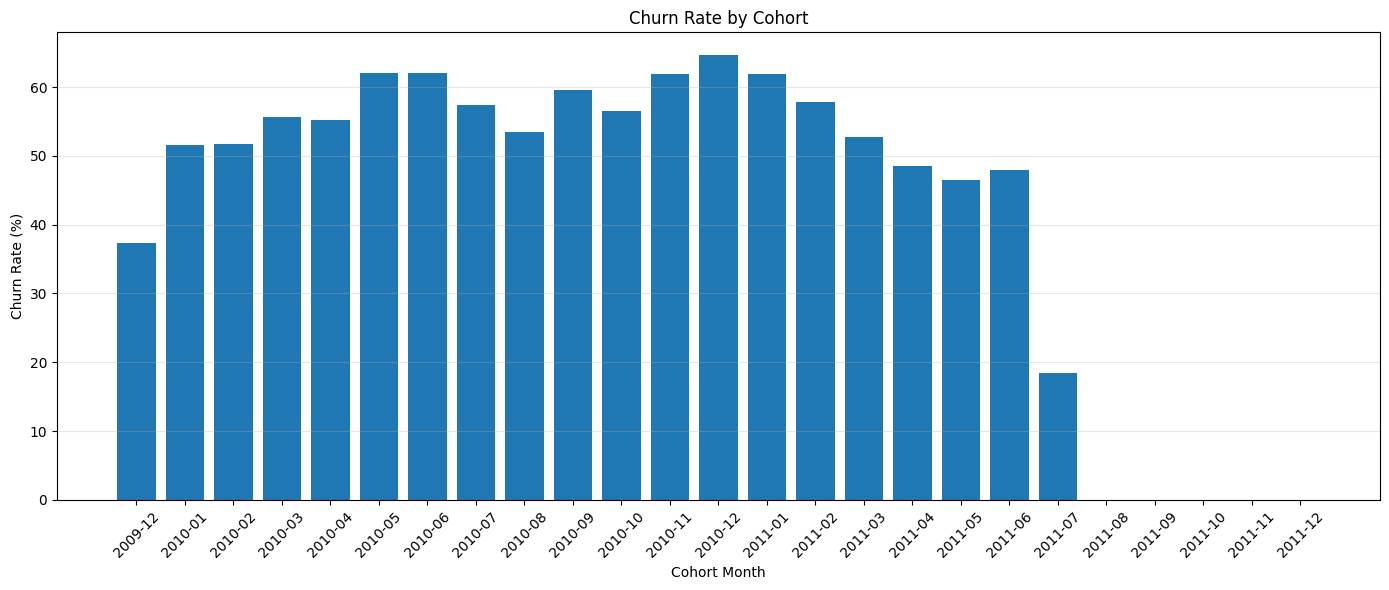

In [265]:
plt.figure(figsize=(14, 6))

plt.bar(churn_by_cohort['CohortMonth'].astype(str), churn_by_cohort['churn_rate'])

plt.title('Churn Rate by Cohort')
plt.xlabel('Cohort Month')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Churn varies substantially across customer cohorts. The earliest cohort (2009-12) has the lowest observed churn rate at around 37%, while most cohorts from 2010-01 to 2011-06 have churn rates between approximately 50% and 65%.

The highest churn is observed among the 2010-12 cohort, at around 65%, indicating that this cohort has the largest share of customers whose last purchase occurred more than 138 days ago.

The later cohorts show lower churn rates, but these values should be interpreted with caution because recent cohorts have had less time to reach the 138-day threshold.

### Churn by country

For customers associated with multiple countries, the country from their latest purchase was used as the most recent and relevant customer location.

In [266]:
# 1 customer per row
customer_country = (df_retail.sort_values('InvoiceDate').groupby(
    'Customer ID', as_index=False).last()[['Customer ID', 'Country']]
)

customer_country.head()

,Customer ID,Country
0,12347,Iceland
1,12349,Italy
2,12350,Norway
3,12351,Unspecified
4,12352,Norway


In [267]:
# churn and country for customers
customer_churn = customer_churn.merge(customer_country, on='Customer ID', how='left')

customer_churn.head()

,Customer ID,last_purchase_date,days_since_last_purchase,churn_status,CohortMonth,is_churned,Country
0,12347,2011-12-07 15:52:00,1,Active,2010-10,0,Iceland
1,12349,2011-11-21 09:51:00,18,Active,2010-04,0,Italy
2,12350,2011-02-02 16:01:00,309,Churned,2011-02,1,Norway
3,12351,2010-11-29 15:23:00,374,Churned,2010-11,1,Unspecified
4,12352,2011-11-03 14:37:00,35,Active,2010-11,0,Norway


In [268]:
# group by сounry
churn_by_country = (customer_churn.groupby('Country').agg(customers=('Customer ID', 'count'), churned=('is_churned', 'sum')).reset_index()
  .sort_values(by='customers', ascending = False))

churn_by_country.head(20)

,Country,customers,churned
35,United Kingdom,4863,2242
14,Germany,91,25
13,France,89,27
30,Spain,30,13
3,Belgium,24,9
24,Netherlands,19,14
28,Portugal,18,11
31,Sweden,15,9
18,Italy,14,6
0,Australia,13,7


For country-level comparison, we focus on the 10 countries with the largest customer bases. Smaller markets are excluded from the main visualization because their churn rates are highly sensitive to individual customers.

In [269]:
top_10_countries = churn_by_country.head(10).copy()

top_10_countries['churn_rate'] = round(top_10_countries['churned'] / top_10_countries['customers'] * 100, 2)

top_10_countries = top_10_countries.sort_values('churn_rate')
top_10_countries.head()

,Country,customers,churned,churn_rate
14,Germany,91,25,27.47
13,France,89,27,30.34
3,Belgium,24,9,37.50
18,Italy,14,6,42.86
30,Spain,30,13,43.33


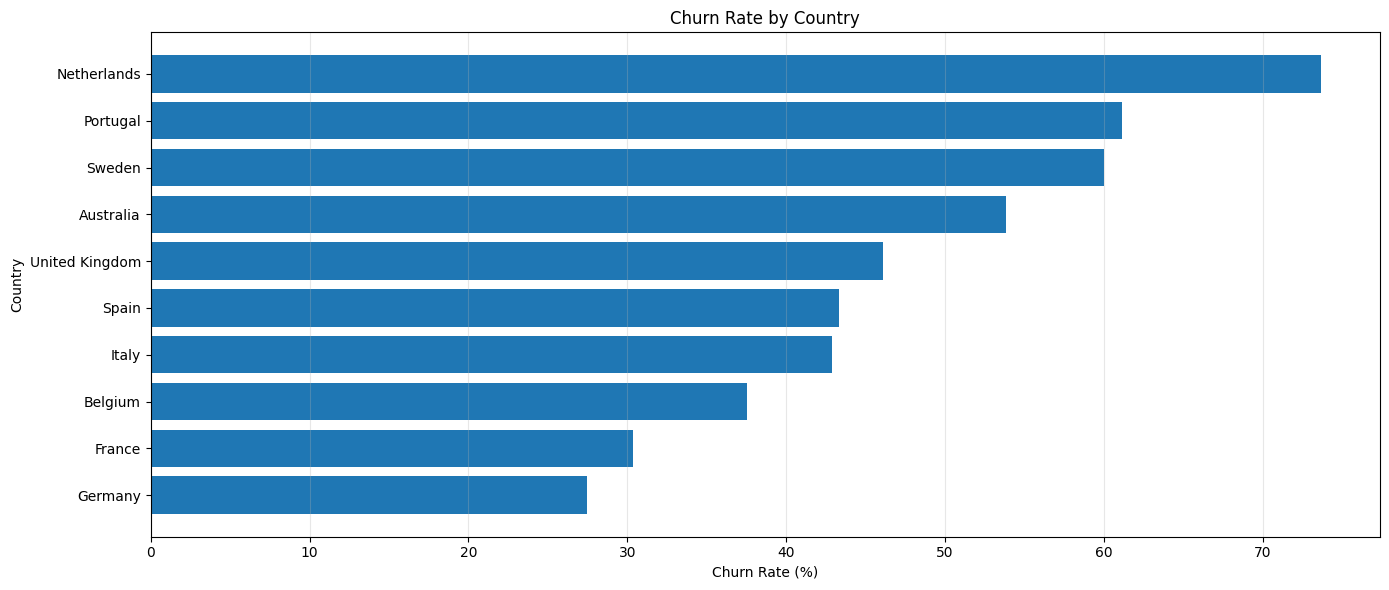

In [270]:
plt.figure(figsize=(14, 6))

plt.barh(top_10_countries['Country'], top_10_countries['churn_rate'])

plt.title('Churn Rate by Country')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Country')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Churn rates vary considerably across the 10 countries with the largest customer bases. The highest observed churn is in the Netherlands (73.7%), followed by Portugal (61.1%) and Sweden (60%). The United Kingdom, which has the largest customer base, has a churn rate of 46.1%.

Germany and France show the lowest churn rates among the selected countries, at approximately 30%, while Belgium has a churn rate of 37.5%.

However, country-level results should be interpreted with caution for smaller markets. For example, the Netherlands has only 19 customers, meaning that its high observed churn rate may be sensitive to a small number of individual customers.

## Customer Lifetime Value

Historical LTV is right-censored by the dataset end date. Customers acquired later have had less time to generate additional purchases, so their observed LTV may underestimate their eventual lifetime value.

### LTV distribution

In [271]:
df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,PurchaseMonth,CohortMonth,MonthSinceFirstPurchase
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,2009-12,0


In [272]:
customer_ltv = df_retail.groupby('Customer ID')['Revenue'].sum().reset_index(name='LTV')
customer_ltv.head()

,Customer ID,LTV
0,12347,4921.53
1,12349,4428.69
2,12350,334.40
3,12351,300.93
4,12352,2849.84


In [273]:
customer_ltv['LTV'].describe()

,LTV
count,5294.000000
mean,2121.860396
std,6113.805772
min,0.000000
25%,320.415000
50%,782.660000
75%,2052.697500
max,291420.810000


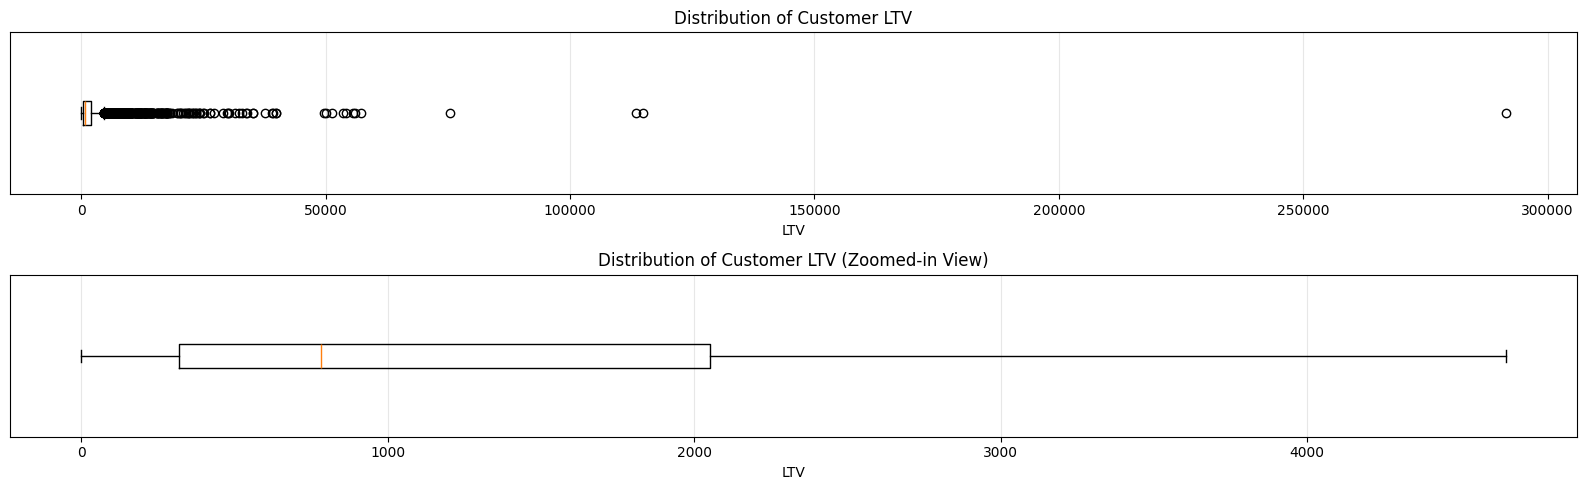

In [274]:
fig, ax = plt.subplots(2, 1, figsize=(16, 5))

ax[0].boxplot(customer_ltv['LTV'],vert=False)
ax[0].set_title("Distribution of Customer LTV")
ax[0].set_xlabel("LTV")
ax[0].grid(axis='x', alpha=0.3)
ax[0].set_yticks([])

ax[1].boxplot(customer_ltv['LTV'],vert=False, showfliers=False)
ax[1].set_title("Distribution of Customer LTV (Zoomed-in View)")
ax[1].set_xlabel("LTV")
ax[1].grid(axis='x', alpha=0.3)
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

Customer LTV is highly right-skewed, with a substantial difference between the mean and median. The median historical LTV is 782.66, while the mean is 2 121.86. The middle 50% of customers have an observed LTV between 320.42 and 2 052.70, while the maximum observed LTV reaches 291 420.81.

The high-LTV customers are not treated as data errors or automatically excluded from the analysis. These values may represent customers who made frequent or high-value purchases over a long period, including customers acquired early in the observation period.

### LTV by Cohort

In [275]:
# 1 customer per row
cohort_ltv = customer_ltv.merge(df_retail[['Customer ID', 'CohortMonth']].drop_duplicates(), on='Customer ID', how='left')
cohort_ltv.head()

,Customer ID,LTV,CohortMonth
0,12347,4921.53,2010-10
1,12349,4428.69,2010-04
2,12350,334.40,2011-02
3,12351,300.93,2010-11
4,12352,2849.84,2010-11


In [276]:
ltv_by_cohort = cohort_ltv.groupby('CohortMonth').agg(
    customers=('Customer ID', 'nunique'), mean_ltv=('LTV', 'mean'), median_ltv=('LTV', 'median')).reset_index()
ltv_by_cohort.head()

,CohortMonth,customers,mean_ltv,median_ltv
0,2009-12,864,5785.902785,2542.040
1,2010-01,349,2800.220347,1639.170
2,2010-02,342,2273.540801,1255.465
3,2010-03,392,2189.931737,1148.930
4,2010-04,268,1739.317015,1058.975


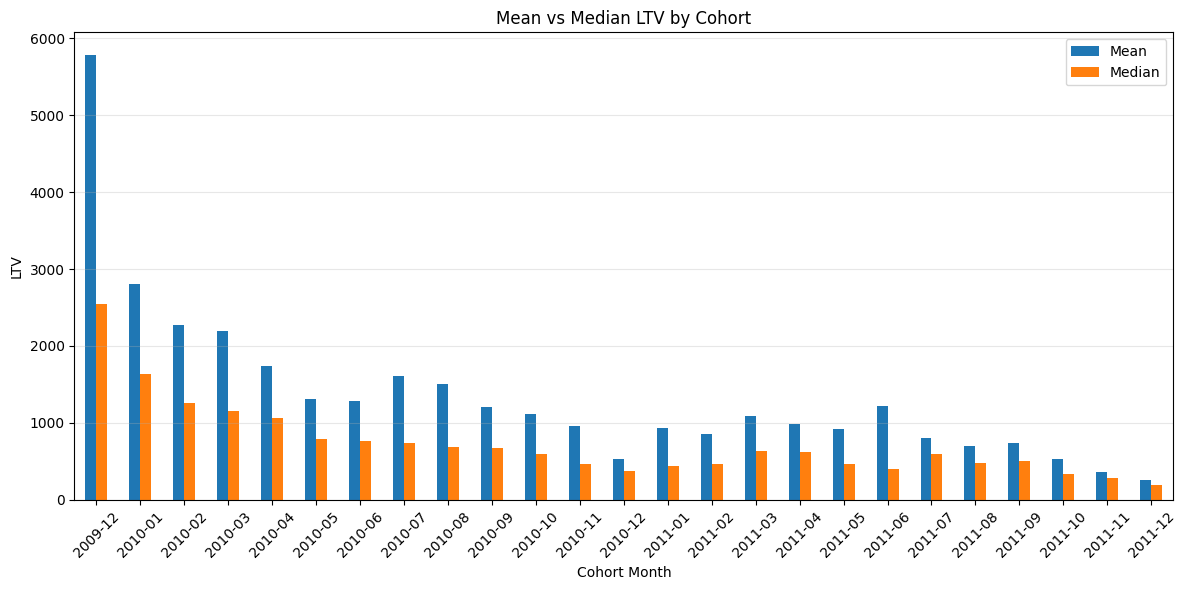

In [277]:
ltv_by_cohort.plot(x='CohortMonth', y=['mean_ltv', 'median_ltv'], kind='bar', figsize=(12, 6))

plt.title('Mean vs Median LTV by Cohort')
plt.xlabel('Cohort Month')
plt.ylabel('LTV')

plt.xticks(rotation=45)
plt.legend(['Mean', 'Median'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Earlier cohorts have higher observed historical LTV, while later cohorts show lower values. The persistent gap between mean and median indicates a highly right-skewed LTV distribution. However, cohort differences are strongly affected by the unequal observation period, so LTV should be interpreted as observed historical value rather than eventual customer lifetime value.

### LTV by Country

In [278]:
# 1 customer per row
customer_country.head()

,Customer ID,Country
0,12347,Iceland
1,12349,Italy
2,12350,Norway
3,12351,Unspecified
4,12352,Norway


In [279]:
# ltv and country for customers
cohort_ltv = cohort_ltv.merge(customer_country, on='Customer ID', how='left')

cohort_ltv.head()

,Customer ID,LTV,CohortMonth,Country
0,12347,4921.53,2010-10,Iceland
1,12349,4428.69,2010-04,Italy
2,12350,334.40,2011-02,Norway
3,12351,300.93,2010-11,Unspecified
4,12352,2849.84,2010-11,Norway


In [280]:
# group by сounry
ltv_country = (cohort_ltv.groupby('Country').agg(
    customers=('Customer ID', 'nunique'), mean_ltv=('LTV', 'mean'), median_ltv=('LTV', 'median'))
    .reset_index().sort_values(by='customers', ascending = False))

ltv_country.head(20)

,Country,customers,mean_ltv,median_ltv
35,United Kingdom,4863,2039.485631,770.030
14,Germany,91,3552.900989,1232.950
13,France,89,2699.071124,973.730
30,Spain,30,1933.761333,560.640
3,Belgium,24,2314.582500,1328.940
24,Netherlands,19,1129.673684,782.950
28,Portugal,18,1434.912222,843.710
31,Sweden,15,1124.474000,732.940
18,Italy,14,1808.225000,1743.505
0,Australia,13,2049.322308,604.550


Countries with a very small number of customers were excluded from the country-level comparison to avoid drawing conclusions based on data from only a few customers.

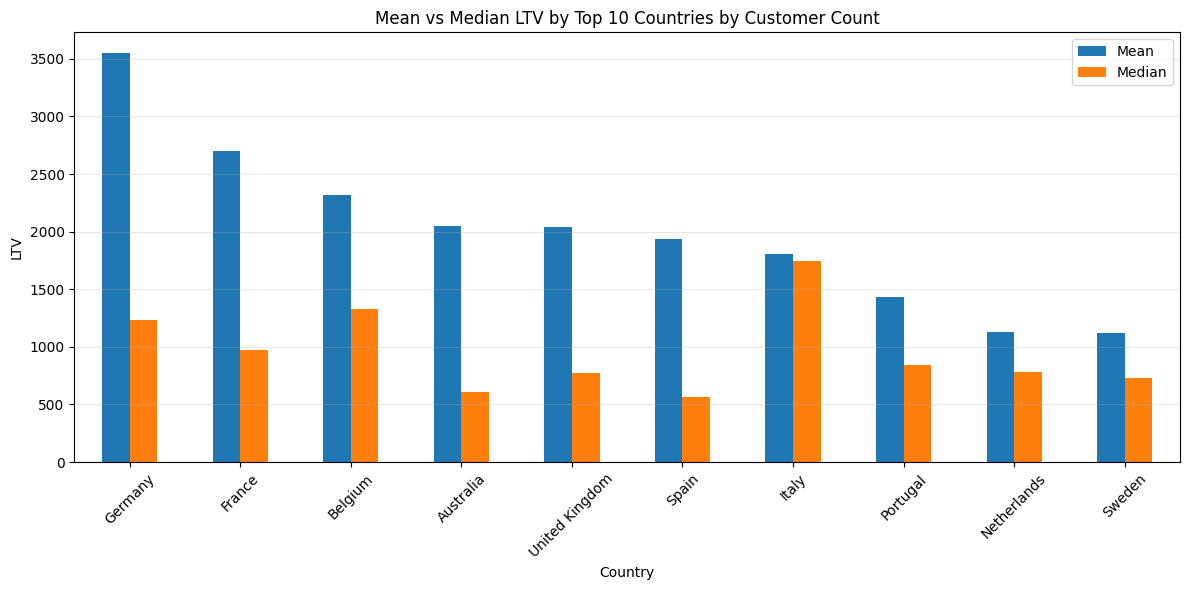

In [281]:
top_10_countries = ltv_country.head(10).copy().sort_values(by='mean_ltv', ascending=False)

top_10_countries.plot(x='Country', y=['mean_ltv', 'median_ltv'], kind='bar', figsize=(12, 6))

plt.title('Mean vs Median LTV by Top 10 Countries by Customer Count')
plt.xlabel('Country')
plt.ylabel('LTV')

plt.xticks(rotation=45)
plt.legend(['Mean', 'Median'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Germany has the highest mean LTV among the selected countries (3 525), followed by France (2 699) and Belgium (2 314). However, median LTV tells a different story: Italy have the highest typical customer value(1 808 vs 1 743), while Germany's median LTV is 1 232.

The UK dominates in customer volume, but not in customer value per customer. Smaller markets may have fewer customers but higher median LTV.

The consistently higher mean compared with median LTV indicates that customer value is right-skewed across most countries, with a smaller number of high-value customers contributing disproportionately to revenue. This is why median LTV is a more representative measure of the typical customer.

## RFM Segmentation

### Recency, Frequency, Monetary

In [282]:
print(analysis_date)
df_retail.head()

2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,PurchaseMonth,CohortMonth,MonthSinceFirstPurchase
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,2009-12,0


In [283]:
df_rfm = df_clean[df_clean['Customer ID'].isin(retail_customers)].copy()

df_rfm.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [284]:
df_rfm['last_purchase'] = df_rfm.groupby('Customer ID')['InvoiceDate'].transform('max')
df_rfm.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,last_purchase
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2011-07-05 12:11:00
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2011-07-05 12:11:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2011-07-05 12:11:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2011-07-05 12:11:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2011-07-05 12:11:00


In [285]:
df_rfm['Recency'] = (analysis_date - df_rfm['last_purchase']).dt.days
df_rfm.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,last_purchase,Recency
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2011-07-05 12:11:00,157
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2011-07-05 12:11:00,157
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2011-07-05 12:11:00,157
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2011-07-05 12:11:00,157
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2011-07-05 12:11:00,157


In [286]:
# 1 row = 1 customer
rfm = df_rfm.groupby('Customer ID').agg(Recency=('Recency', 'first'), Frequency=('Invoice', 'nunique'), Monetary=('Revenue', 'sum')).reset_index()
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12347,1,8,4921.53
1,12349,18,4,4428.69
2,12350,309,1,334.40
3,12351,374,1,300.93
4,12352,35,10,2849.84


In [287]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5294.000000,5294.000000,5294.000000,5294.000000
mean,15339.216094,203.578580,6.108802,2121.860396
std,1709.812877,210.231721,12.160922,6113.805772
min,12347.000000,0.000000,1.000000,0.000000
25%,13867.750000,25.000000,1.000000,320.415000
50%,15335.500000,102.500000,3.000000,782.660000
75%,16824.750000,380.000000,7.000000,2052.697500
max,18287.000000,738.000000,398.000000,291420.810000


RFM metrics were calculated for 5 294 retail customers. Recency measures the number of days since the customer's last purchase, Frequency represents the number of unique invoices and Monetary represents total customer revenue.

Few retail customers have zero Monetary value because their only recorded transaction was a zero-priced technical/test item. These records were retained consistently with the earlier data-cleaning decision, as zero-revenue records represent only 0.01% of the cleaned dataset and are not expected to materially affect the analysis.

### RFM scores

In [288]:
rfm['R'] = pd.qcut(rfm['Recency'], q=3, labels=[3,2,1])

rfm['F'] = pd.qcut(rfm['Frequency'], q=3, labels=[1,2,3])

rfm['M'] = pd.qcut(rfm['Monetary'], q=3, labels=[1,2,3])

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R,F,M
0,12347,1,8,4921.53,3,3,3
1,12349,18,4,4428.69,3,2,3
2,12350,309,1,334.40,1,1,1
3,12351,374,1,300.93,1,1,1
4,12352,35,10,2849.84,3,3,3


Three RFM score levels (1–3) are used because Frequency distribution is highly discrete, with many customers having the same number of purchases. This prevents qcut() from creating four or five unique quantile groups. Using three groups provides consistent scoring across all three RFM dimensions while preserving meaningful differences between low, medium and high customer activity.

In [289]:
rfm['rfm_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R,F,M,rfm_score
0,12347,1,8,4921.53,3,3,3,333
1,12349,18,4,4428.69,3,2,3,323
2,12350,309,1,334.40,1,1,1,111
3,12351,374,1,300.93,1,1,1,111
4,12352,35,10,2849.84,3,3,3,333


### RFM segments

In [290]:
rfm['rfm_total'] = (rfm['R'].astype(int) + rfm['F'].astype(int) + rfm['M'].astype(int))
rfm['rfm_total'].value_counts().sort_index()

,count
rfm_total,
3,973
4,776
5,779
6,612
7,634
8,621
9,899


In [291]:
# define customer segments

def segment_customers(value):
    if value == 9:
        return 'Best Customer'
    elif value >= 7:
        return 'Loyal Customer'
    elif value >= 5:
        return 'Average Customer'
    else:
        return 'At Risk / Lost Customer'

rfm['customer_segment'] = rfm['rfm_total'].apply(segment_customers)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R,F,M,rfm_score,rfm_total,customer_segment
0,12347,1,8,4921.53,3,3,3,333,9,Best Customer
1,12349,18,4,4428.69,3,2,3,323,8,Loyal Customer
2,12350,309,1,334.40,1,1,1,111,3,At Risk / Lost Customer
3,12351,374,1,300.93,1,1,1,111,3,At Risk / Lost Customer
4,12352,35,10,2849.84,3,3,3,333,9,Best Customer


In [292]:
rfm['customer_segment'].value_counts()


,count
customer_segment,
At Risk / Lost Customer,1749
Average Customer,1391
Loyal Customer,1255
Best Customer,899


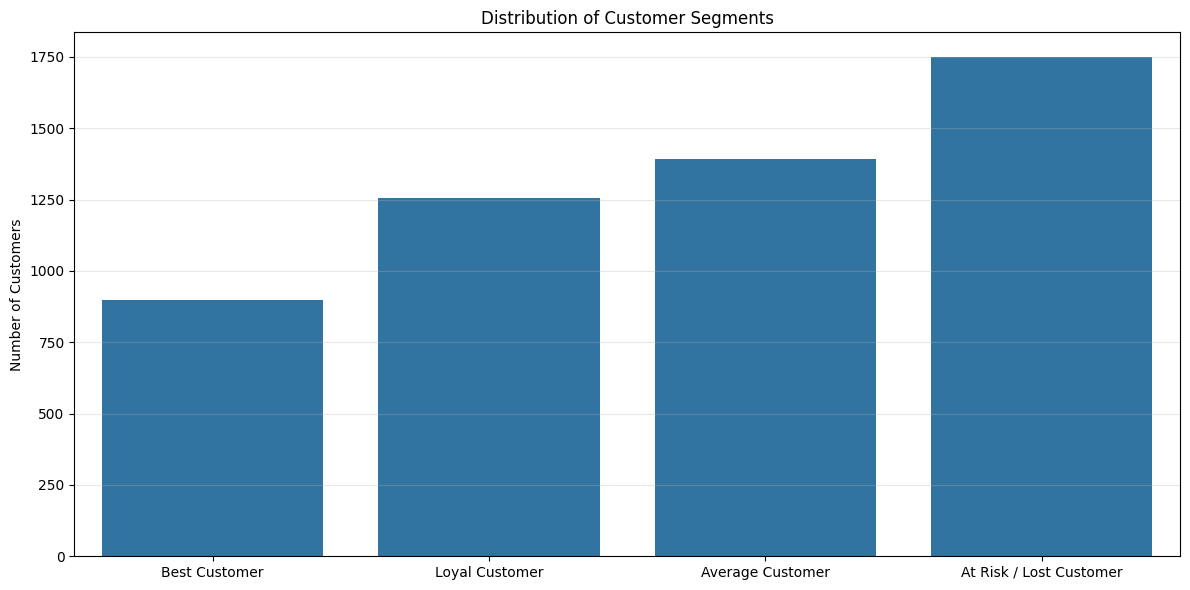

In [293]:
plt.figure (figsize = (12,6))
sns.countplot(data = rfm, x='customer_segment', order = ['Best Customer', 'Loyal Customer', 'Average Customer', 'At Risk / Lost Customer'])
plt.title('Distribution of Customer Segments')
plt.xlabel('')
plt.ylabel('Number of Customers')


plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


The segmentation shows a large group of At Risk / Lost Customers, while Best Customers form the smallest segment. This suggests that customer engagement is uneven, with a substantial share of customers showing weak or outdated purchasing activity.

## RFM + Customer Lifecycle Analysis

### RFM Segment by Cohort

In [294]:
customer_cohort.head()

,Customer ID,CohortMonth
0,13085,2009-12
12,13078,2009-12
31,15362,2009-12
71,12682,2009-12
90,18087,2009-12


In [295]:
rfm = rfm.merge(customer_cohort, on='Customer ID', how='left')
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R,F,M,rfm_score,rfm_total,customer_segment,CohortMonth
0,12347,1,8,4921.53,3,3,3,333,9,Best Customer,2010-10
1,12349,18,4,4428.69,3,2,3,323,8,Loyal Customer,2010-04
2,12350,309,1,334.40,1,1,1,111,3,At Risk / Lost Customer,2011-02
3,12351,374,1,300.93,1,1,1,111,3,At Risk / Lost Customer,2010-11
4,12352,35,10,2849.84,3,3,3,333,9,Best Customer,2010-11


In [296]:
rfm_cohort = rfm.groupby(['CohortMonth', 'customer_segment']).size().unstack(fill_value=0)

rfm_cohort.head()

customer_segment,At Risk / Lost Customer,Average Customer,Best Customer,Loyal Customer
CohortMonth,,,,
2009-12,139,125,357,243
2010-01,77,76,84,112
2010-02,96,74,51,121
2010-03,127,81,71,113
2010-04,87,60,47,74


In [297]:
# transforming into percents and set the 'correct' order
rfm_cohort_pct = rfm_cohort.div(rfm_cohort.sum(axis=1), axis=0) * 100

order = ['Best Customer', 'Loyal Customer', 'Average Customer', 'At Risk / Lost Customer']

rfm_cohort_pct = rfm_cohort_pct[order]
rfm_cohort_pct.head()

customer_segment,Best Customer,Loyal Customer,Average Customer,At Risk / Lost Customer
CohortMonth,,,,
2009-12,41.319444,28.125000,14.467593,16.087963
2010-01,24.068768,32.091691,21.776504,22.063037
2010-02,14.912281,35.380117,21.637427,28.070175
2010-03,18.112245,28.826531,20.663265,32.397959
2010-04,17.537313,27.611940,22.388060,32.462687


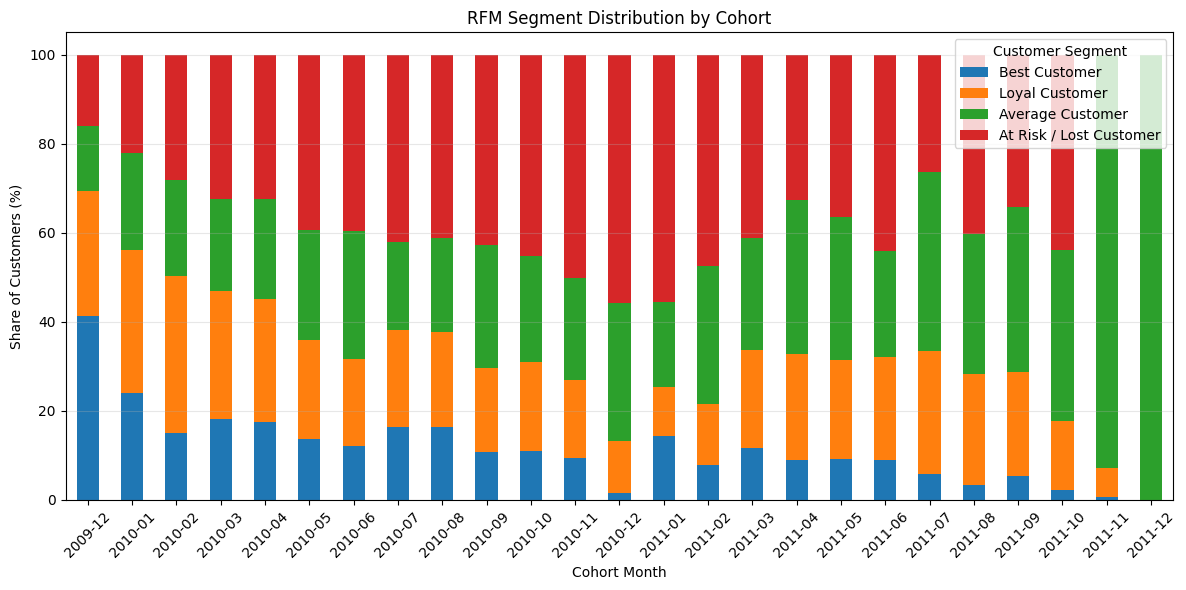

In [298]:
rfm_cohort_pct.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title('RFM Segment Distribution by Cohort')
plt.xlabel('Cohort Month')
plt.ylabel('Share of Customers (%)')
plt.legend(title='Customer Segment')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

The analysis shows that earlier cohorts tend to contain a larger share of high-value customers (Best and Loyal), while later cohorts have a higher share of Average and At Risk / Lost Customers. This pattern may partly reflect customer lifecycle, since recent cohorts have had less time to make repeat purchases and build higher RFM scores.

### Retention by RFM segment

In [299]:
df_retail.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,PurchaseMonth,CohortMonth,MonthSinceFirstPurchase
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12,0


In [300]:
rfm.head(1)

,Customer ID,Recency,Frequency,Monetary,R,F,M,rfm_score,rfm_total,customer_segment,CohortMonth
0,12347,1,8,4921.53,3,3,3,333,9,Best Customer,2010-10


In [301]:
df_retention = df_retail.merge(rfm[['Customer ID', 'customer_segment']], on='Customer ID', how='left')
df_retention.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,PurchaseMonth,CohortMonth,MonthSinceFirstPurchase,customer_segment
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,2009-12,0,Loyal Customer


In [302]:
# active customers per months
retention = pd.pivot_table(df_retention, index='customer_segment', columns='MonthSinceFirstPurchase',
  values='Customer ID', aggfunc='nunique', fill_value=0).reindex(order)

retention.head()

MonthSinceFirstPurchase,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
customer_segment,,,,,,,,,,,,,,,,,,,,,
Best Customer,899,437,462,479,456,441,484,447,417,404,...,362,354,353,336,328,325,315,280,319,158
Loyal Customer,1255,442,444,437,392,371,340,346,297,274,...,197,177,190,148,161,120,93,67,43,8
Average Customer,1391,248,221,205,182,150,142,132,116,112,...,44,38,30,20,25,35,9,10,4,1
At Risk / Lost Customer,1749,79,53,69,43,48,31,26,19,18,...,2,2,3,1,1,0,0,1,0,0


In [303]:
# to percent
retention_pct = round(retention.div(retention[0], axis=0) * 100,2)
retention_pct.head()

MonthSinceFirstPurchase,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
customer_segment,,,,,,,,,,,,,,,,,,,,,
Best Customer,100.0,48.61,51.39,53.28,50.72,49.05,53.84,49.72,46.38,44.94,...,40.27,39.38,39.27,37.37,36.48,36.15,35.04,31.15,35.48,17.58
Loyal Customer,100.0,35.22,35.38,34.82,31.24,29.56,27.09,27.57,23.67,21.83,...,15.70,14.10,15.14,11.79,12.83,9.56,7.41,5.34,3.43,0.64
Average Customer,100.0,17.83,15.89,14.74,13.08,10.78,10.21,9.49,8.34,8.05,...,3.16,2.73,2.16,1.44,1.80,2.52,0.65,0.72,0.29,0.07
At Risk / Lost Customer,100.0,4.52,3.03,3.95,2.46,2.74,1.77,1.49,1.09,1.03,...,0.11,0.11,0.17,0.06,0.06,0.00,0.00,0.06,0.00,0.00


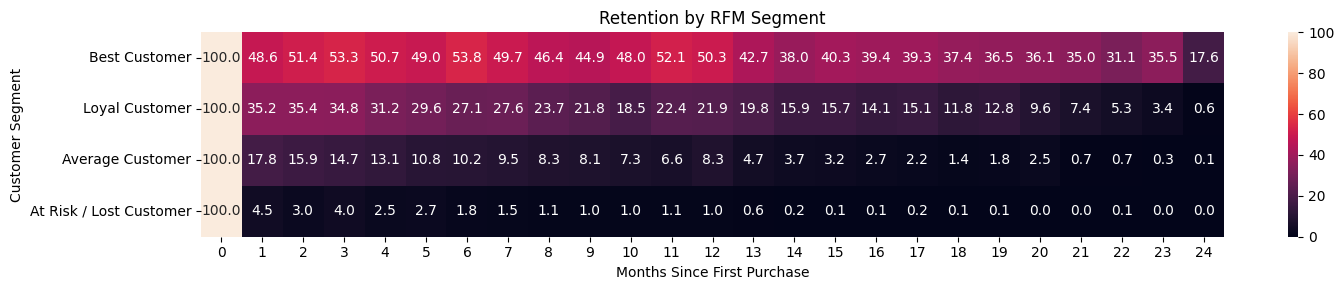

In [304]:
plt.figure(figsize=(15, 3))

sns.heatmap(
    retention_pct,
    annot=True,
    fmt=".1f",
    vmin=0,
    vmax=100
)

plt.title('Retention by RFM Segment')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Customer Segment')

plt.tight_layout()
plt.show()

Retention strongly differs across RFM segments. Best Customers demonstrate the strongest long-term retention, with 17.6% remaining active 24 months after their first purchase. Loyal Customers show moderate initial retention but gradually decline over time, while Average and At Risk / Lost Customers have much weaker retention and approach zero in the long term. This indicates that higher-value RFM segments are also more likely to remain active over time.

### LTV by RFM segment

In [305]:
cohort_ltv.head(1)

,Customer ID,LTV,CohortMonth,Country
0,12347,4921.53,2010-10,Iceland


In [306]:
rfm.head(1)

,Customer ID,Recency,Frequency,Monetary,R,F,M,rfm_score,rfm_total,customer_segment,CohortMonth
0,12347,1,8,4921.53,3,3,3,333,9,Best Customer,2010-10


In [307]:
ltv_rfm = cohort_ltv.merge(rfm[['Customer ID','customer_segment']], on='Customer ID', how='left')

ltv_rfm.head(1)

,Customer ID,LTV,CohortMonth,Country,customer_segment
0,12347,4921.53,2010-10,Iceland,Best Customer


In [308]:
ltv_by_segment = (ltv_rfm.groupby('customer_segment').agg(
    customers=('Customer ID', 'nunique'),
    mean_ltv=('LTV', 'mean'),
    median_ltv=('LTV', 'median')).reindex(order))

ltv_by_segment

,customers,mean_ltv,median_ltv
customer_segment,,,
Best Customer,899,7163.949293,4267.15
Loyal Customer,1255,2523.261512,1747.98
Average Customer,1391,796.692603,676.99
At Risk / Lost Customer,1749,296.081138,246.50


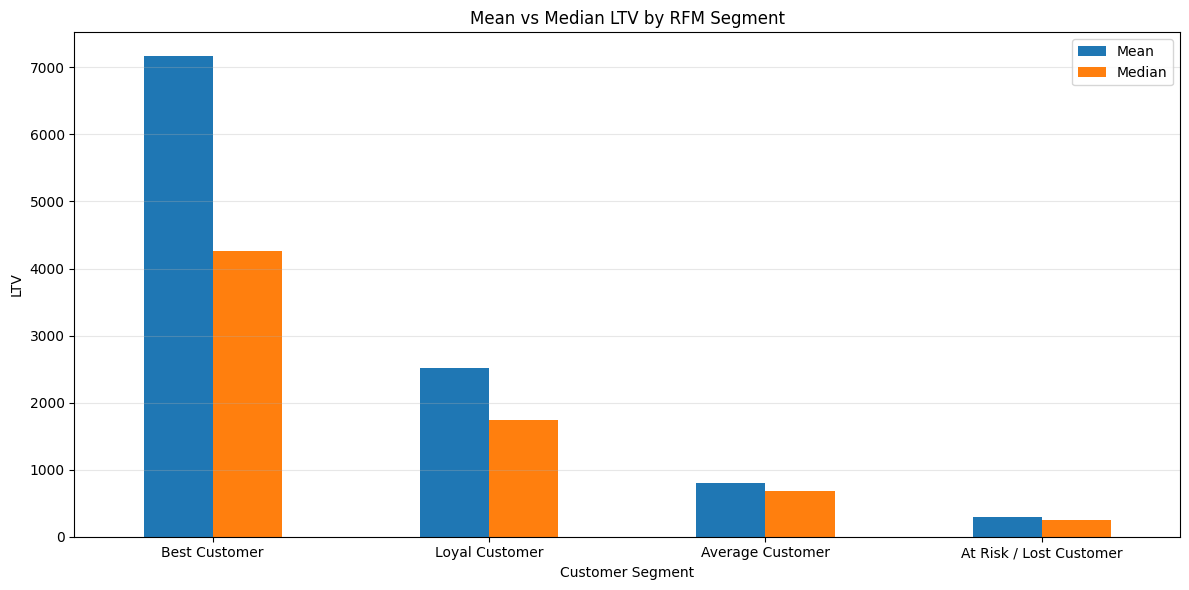

In [309]:
ltv_by_segment.plot(y=['mean_ltv', 'median_ltv'], kind='bar', figsize=(12, 6))

plt.title('Mean vs Median LTV by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('LTV')

plt.xticks(rotation=0)
plt.legend(['Mean', 'Median'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

LTV strongly differs across RFM segments. Best Customers have the highest lifetime value, with a mean LTV of 7 158 and a median of 4 277. Loyal Customers show substantially lower but still strong LTV, while Average Customers have a much lower customer value. At Risk / Lost Customers have the lowest LTV, with a mean of only 296.

The large gap between mean and median LTV among Best Customers also indicates a wider spread in customer value within this segment, suggesting that a small number of particularly high-value customers may drive part of the average.

This confirms that the RFM segmentation effectively separates customers by economic value: customers with stronger RFM profiles tend to generate substantially higher lifetime revenue.

### Сhurn by RFM segment

In [310]:
customer_churn.head(1)

,Customer ID,last_purchase_date,days_since_last_purchase,churn_status,CohortMonth,is_churned,Country
0,12347,2011-12-07 15:52:00,1,Active,2010-10,0,Iceland


In [311]:
rfm.head(1)

,Customer ID,Recency,Frequency,Monetary,R,F,M,rfm_score,rfm_total,customer_segment,CohortMonth
0,12347,1,8,4921.53,3,3,3,333,9,Best Customer,2010-10


In [312]:
rfm_churn = rfm.merge(customer_churn[['Customer ID', 'is_churned']], on='Customer ID', how='left')

rfm_churn.head()

,Customer ID,Recency,Frequency,Monetary,R,F,M,rfm_score,rfm_total,customer_segment,CohortMonth,is_churned
0,12347,1,8,4921.53,3,3,3,333,9,Best Customer,2010-10,0
1,12349,18,4,4428.69,3,2,3,323,8,Loyal Customer,2010-04,0
2,12350,309,1,334.40,1,1,1,111,3,At Risk / Lost Customer,2011-02,1
3,12351,374,1,300.93,1,1,1,111,3,At Risk / Lost Customer,2010-11,1
4,12352,35,10,2849.84,3,3,3,333,9,Best Customer,2010-11,0


In [313]:
# group by segment
churn_by_segment = rfm_churn.groupby('customer_segment').agg(
    customers=('Customer ID', 'count'), churned=('is_churned', 'sum'), churn_rate=('is_churned', 'mean')).reindex(order).reset_index()
churn_by_segment['churn_rate'] = churn_by_segment['churn_rate'] * 100

churn_by_segment.head()

,customer_segment,customers,churned,churn_rate
0,Best Customer,899,0,0.000000
1,Loyal Customer,1255,260,20.717131
2,Average Customer,1391,624,44.859813
3,At Risk / Lost Customer,1749,1532,87.592910


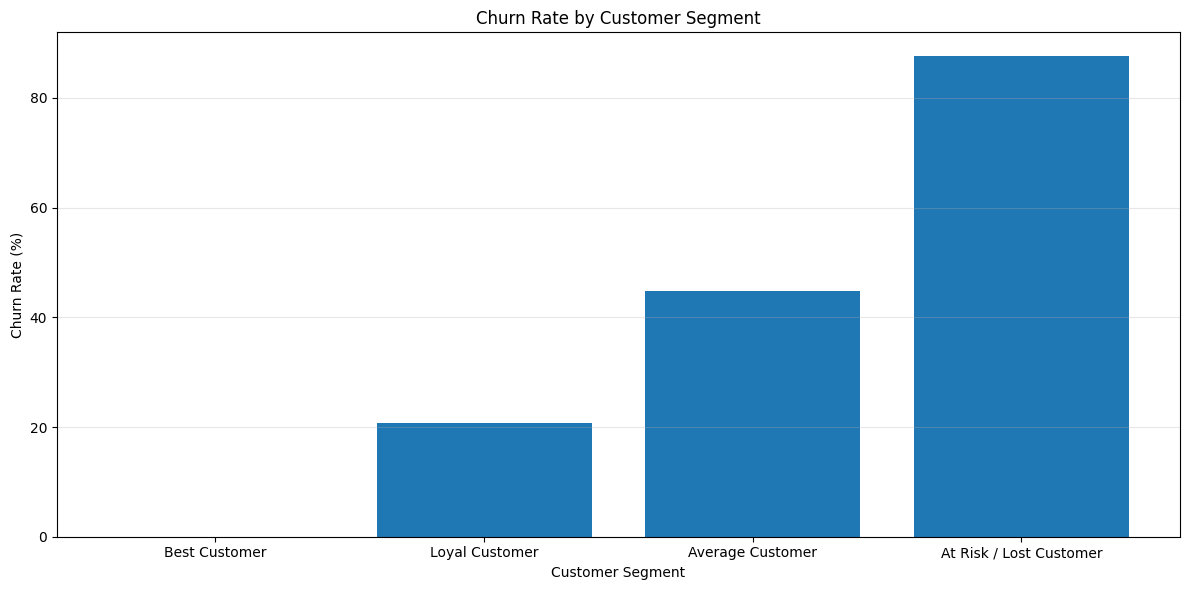

In [314]:
plt.figure(figsize=(12, 6))

plt.bar(churn_by_segment['customer_segment'], churn_by_segment['churn_rate'])

plt.title('Churn Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

RFM segmentation strongly differentiates customers by churn risk. Best Customers show no churn, while churn increases progressively across Loyal and Average segments, reaching 87.6% among At Risk / Lost Customers. This confirms that RFM segmentation can be effectively used to identify customers at different levels of churn risk and prioritize retention efforts.

## Insights & Recommendations

### Key Insights


1.  **The customer base consists of two distinct behavioral groups**

Wholesale customers account for only about 10% of the total number of customers, but generate 35.35% of revenue. Their median average order value (AOV) is approximately 2.5 times higher than that of retail customers.

2.   **Retention declines substantially over the customer lifecycle**

Cohort analysis shows that retention declines significantly as the time since the first purchase increases.

And RFM retention reveals something even more interesting: Best Customers maintain significantly higher long-term activity than Average and At Risk / Lost Customers.

For Best Customers retention after 24 months is 17.6%.

3.   **Customer churn is one of the main challenges in the customer lifecycle**

Our data-driven churn threshold is 138 days. In other words, the absence of purchases for more than 138 days is used as an operational definition of churn.

And according to RFM:

* Best Customers → 0% churn
* Loyal → 20.7%
* Average → 44.9%
* At-risk / Lost → 87.6%

Segmentation using the RFM model is a practical way to prioritize customers based on their risk of churn.

4.   **Customer value varies significantly across RFM segments**

* Best Customers → 4267£ median LTV
* Loyal → 1748£
* Average → 677£
* At-risk / Lost → 247£

Best Customers have a huge difference in lifetime value compared to the rest.

This confirms that RFM segmentation truly categorizes customers based on their economic value.

5.   **Customer cohorts behave differently**

Earlier cohorts contain a higher proportion of Best and Loyal Customers, while later cohorts have a higher proportion of Average and At Risk / Lost customers.

This pattern may partly reflect the customer lifecycle, since recent cohorts have had less time to make repeat purchases and build higher RFM scores.



### Overall Conclusion

The analysis shows that customer value and retention are strongly differentiated across customer segments. A relatively small group of high-value customers generates substantial economic value and demonstrates stronger long-term retention, while At Risk / Lost customers show significantly lower LTV and much higher churn.

The main business opportunity is therefore not only acquiring new customers, but increasing retention and customer value through targeted lifecycle strategies — protecting high-value customers, converting Loyal customers into Best customers and reactivating customers at risk of churn.

In [315]:
# Customer master table (1 row = 1 retail customer)
customer_master = (
    customer_segments
    .merge(rfm[['Customer ID','R','F','M','rfm_score','customer_segment']], on='Customer ID', how='left')
    .merge(customer_churn[['Customer ID','churn_status','days_since_last_purchase','Country']], on='Customer ID', how='left')
    .merge(customer_ltv, on='Customer ID', how='left')
    .merge(customer_cohort, on='Customer ID', how='left')
)
customer_master.to_csv('customer_master.csv', index=False)

# Cohort retention (customer-based)
cohort_retention.to_csv('cohort_retention.csv', index=False)

# Cohort revenue retention
cohort_revenue.to_csv('cohort_revenue.csv', index=False)

# New vs Returning by month
new_returning_long = new_returning_monthly.melt(
    id_vars='PurchaseMonth',
    value_vars=['New', 'Returning'],
    var_name='customer_status',
    value_name='Customers')

new_returning_long.to_csv('new_returning_monthly.csv', index=False)

# Retention by RFM segment
retention_pct.reset_index().melt(id_vars='customer_segment', var_name='MonthSinceFirstPurchase', value_name='retention_pct').to_csv(
    'retention_by_segment.csv', index=False)

# Monthly sales
monthly_sales = (df_retail.groupby('PurchaseMonth').agg(Revenue=('Revenue', 'sum'), Orders=('Invoice', 'nunique')).reset_index())
monthly_sales.to_csv('monthly_sales.csv', index=False)

In [316]:
from google.colab import files

files.download('customer_master.csv')
files.download('cohort_revenue.csv')
files.download('cohort_retention.csv')
files.download('new_returning_monthly.csv')
files.download('retention_by_segment.csv')
files.download('monthly_sales.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>